# 🔥 Indoor Fire Detection — RNN · CNN-1D · TCN

**Dataset:** Indoor Fire Dataset with Distributed Multi-Sensor Nodes (Mendeley, 2023)  
**Labels:** `Background` · `Fire` · `Nuisance` (ternary classification)  
**Nodes:** 9 distributed sensor nodes · 305,304 rows · 10-second sampling  
**Strategy:** Train on 7 nodes, validate/test on held-out nodes (spatial generalisation)  

---

## 0. Install & Import

In [2]:
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pathlib import Path
ROOT_DIR = Path.cwd().parent.parent
DATA_PATH = ROOT_DIR / 'data' / 'Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv'
tf.random.set_seed(42)
np.random.seed(42)

# ── Colours ──
MODEL_COLORS  = {'RNN': '#4A90D9', 'CNN1D': '#27AE60', 'TCN': '#E07B39'}
LABEL_COLORS  = {'Background': '#95A5A6', 'Fire': '#E74C3C', 'Nuisance': '#F39C12'}
CLASS_NAMES   = ['Background', 'Fire', 'Nuisance']   # alphabetical → LabelEncoder order

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'CPU only')


from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv'

Mounted at /content/drive


## 1. Load & Clean Data

In [3]:

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601', utc=True)
df = df.sort_values(['Sensor_ID', 'Date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print('\nternary_label distribution:')
tc = df['ternary_label'].value_counts()
for label, cnt in tc.items():
    print(f'  {label:<12}: {cnt:>7,} ({cnt/len(df)*100:.1f}%)')

Shape: (305304, 19)

ternary_label distribution:
  Background  : 253,327 (83.0%)
  Fire        :  38,148 (12.5%)
  Nuisance    :  13,829 (4.5%)


## 2. Feature Engineering

In [4]:
# ── Drop redundant PM columns (corr > 0.98 from EDA) and low-importance CO2 ──
DROP_COLS = ['PM25_Room', 'PM40_Room', 'PM100_Room', 'CO2_Room']

BASE_FEATURES = [
    'CO_Room', 'H2_Room', 'Humidity_Room',
    'PM05_Room', 'PM10_Room', 'PM_Room_Typical_Size', 'PM_Total_Room',
    'Temperature_Room', 'UV_Room', 'VOC_Room_RAW',
]


def add_features(group: pd.DataFrame) -> pd.DataFrame:
    """Add delta, rolling, and ratio features within each sensor node."""
    g = group.copy()

    for col in ['CO_Room', 'H2_Room', 'PM05_Room', 'PM_Total_Room', 'VOC_Room_RAW']:
        g[f'delta_{col}']      = g[col].diff().fillna(0)
        g[f'roll_mean_{col}']  = g[col].rolling(6, min_periods=1).mean()   # 1-min window
        g[f'roll_std_{col}']   = g[col].rolling(6, min_periods=1).std().fillna(0)

    g['VOC_CO_ratio']   = g['VOC_Room_RAW'] / (g['CO_Room'].abs() + 0.1)
    g['PM_size_ratio']  = g['PM_Room_Typical_Size'] / (g['PM05_Room'] + 1)
    g['UV_norm']        = g['UV_Room'] / (g['UV_Room'].max() + 1e-9)

    return g


df = df.groupby('Sensor_ID', group_keys=False).apply(add_features)

ENGINEERED = [
    f'{prefix}_{col}'
    for prefix in ['delta', 'roll_mean', 'roll_std']
    for col in ['CO_Room', 'H2_Room', 'PM05_Room', 'PM_Total_Room', 'VOC_Room_RAW']
]
EXTRA = ['VOC_CO_ratio', 'PM_size_ratio', 'UV_norm']

FEATURE_COLS = BASE_FEATURES + ENGINEERED + EXTRA
print(f'Feature count: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Feature count: 28
['CO_Room', 'H2_Room', 'Humidity_Room', 'PM05_Room', 'PM10_Room', 'PM_Room_Typical_Size', 'PM_Total_Room', 'Temperature_Room', 'UV_Room', 'VOC_Room_RAW', 'delta_CO_Room', 'delta_H2_Room', 'delta_PM05_Room', 'delta_PM_Total_Room', 'delta_VOC_Room_RAW', 'roll_mean_CO_Room', 'roll_mean_H2_Room', 'roll_mean_PM05_Room', 'roll_mean_PM_Total_Room', 'roll_mean_VOC_Room_RAW', 'roll_std_CO_Room', 'roll_std_H2_Room', 'roll_std_PM05_Room', 'roll_std_PM_Total_Room', 'roll_std_VOC_Room_RAW', 'VOC_CO_ratio', 'PM_size_ratio', 'UV_norm']


## 3. Train / Validation / Test Split

> **Strategy — node-based split (spatial generalisation)**  
> Train on 7 nodes, validate on 1, test on 1. This tests whether the model generalises  
> to an unseen sensor position — more realistic than random-row splitting.

In [5]:
ALL_NODES  = sorted(df['Sensor_ID'].unique())
VAL_NODE   = ALL_NODES[-2]   # Sensorknoten0015
TEST_NODE  = ALL_NODES[-1]   # Sensorknoten0016
TRAIN_NODES = [n for n in ALL_NODES if n not in (VAL_NODE, TEST_NODE)]

print(f'Train nodes ({len(TRAIN_NODES)}): {TRAIN_NODES}')
print(f'Val node  : {VAL_NODE}')
print(f'Test node : {TEST_NODE}')

train_df = df[df['Sensor_ID'].isin(TRAIN_NODES)].reset_index(drop=True)
val_df   = df[df['Sensor_ID'] == VAL_NODE].reset_index(drop=True)
test_df  = df[df['Sensor_ID'] == TEST_NODE].reset_index(drop=True)

print(f'\nTrain: {len(train_df):,} rows')
print(f'Val  : {len(val_df):,} rows')
print(f'Test : {len(test_df):,} rows')

# Encode labels
le = LabelEncoder()   # Background=0, Fire=1, Nuisance=2
le.fit(df['ternary_label'])
CLASS_NAMES = list(le.classes_)
print(f'\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Fit scaler on train only
scaler = StandardScaler()
X_train_raw = scaler.fit_transform(train_df[FEATURE_COLS].fillna(0))
X_val_raw   = scaler.transform(val_df[FEATURE_COLS].fillna(0))
X_test_raw  = scaler.transform(test_df[FEATURE_COLS].fillna(0))

y_train_raw = le.transform(train_df['ternary_label'])
y_val_raw   = le.transform(val_df['ternary_label'])
y_test_raw  = le.transform(test_df['ternary_label'])

Train nodes (7): ['Sensorknoten0008', 'Sensorknoten0009', 'Sensorknoten0010', 'Sensorknoten0011', 'Sensorknoten0012', 'Sensorknoten0013', 'Sensorknoten0014']
Val node  : Sensorknoten0015
Test node : Sensorknoten0016

Train: 237,519 rows
Val  : 33,893 rows
Test : 33,892 rows

Class mapping: {'Background': np.int64(0), 'Fire': np.int64(1), 'Nuisance': np.int64(2)}


## 4. Sliding Window

In [6]:
WINDOW_SIZE = 18    # 18 × 10 s = 3-minute lookback
STRIDE      = 2
N_FEATURES  = len(FEATURE_COLS)
N_CLASSES   = len(CLASS_NAMES)


def make_windows(
    X: np.ndarray,
    y: np.ndarray,
    window: int = WINDOW_SIZE,
    stride: int = STRIDE,
) -> tuple[np.ndarray, np.ndarray]:
    """Slide a window over a single node's time series.
    Label = the class at the LAST timestep of each window.
    """
    Xs, ys = [], []
    for i in range(0, len(X) - window + 1, stride):
        Xs.append(X[i : i + window])
        ys.append(y[i + window - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)


X_train, y_train = make_windows(X_train_raw, y_train_raw)
X_val,   y_val   = make_windows(X_val_raw,   y_val_raw)
X_test,  y_test  = make_windows(X_test_raw,  y_test_raw)

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}   y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

X_train: (118751, 18, 28)   y_train: (118751,)
X_val  : (16938, 18, 28)   y_val  : (16938,)
X_test : (16938, 18, 28)   y_test : (16938,)


## 5. Class Weights (handle 83 % Background imbalance)

In [7]:
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=y_train,
)
# Priority boost: Fire × 1.5, Nuisance × 1.5 (both rarer and safety-critical)
PRIORITY = np.array([1.0, 1.5, 1.5])   # Background, Fire, Nuisance
class_weights = dict(enumerate(raw_weights * PRIORITY))

print('Class weights:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i}] {name:<12}: {class_weights[i]:.3f}')

Class weights:
  [0] Background  : 0.402
  [1] Fire        : 4.003
  [2] Nuisance    : 10.967


## 6. Focal Loss

In [8]:
class FocalLoss(keras.losses.Loss):
    """Multi-class Focal Loss.

    alpha : per-class weight array — [Background, Fire, Nuisance]
    gamma : focusing parameter (higher → harder examples get more weight)
    """

    def __init__(self, alpha=None, gamma: float = 2.0, **kwargs):
        super().__init__(**kwargs)
        if alpha is None:
            alpha = [0.15, 0.55, 0.30]   # Background low, Fire high, Nuisance medium
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = float(gamma)

    def call(self, y_true, y_pred):
        y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0)
        one_hot  = tf.one_hot(y_true, depth=len(self.alpha))
        p_t      = tf.reduce_sum(y_pred * one_hot, axis=-1)
        ce       = -tf.math.log(p_t)
        focal_w  = tf.pow(1.0 - p_t, self.gamma)
        alpha_t  = tf.gather(self.alpha, y_true)
        return tf.reduce_mean(alpha_t * focal_w * ce)

    def get_config(self):
        return {'alpha': self.alpha.numpy().tolist(), 'gamma': self.gamma}


focal_loss = FocalLoss(alpha=[0.15, 0.55, 0.30], gamma=2.0)
print('Focal Loss ready — alpha: Background=0.15, Fire=0.55, Nuisance=0.30')

Focal Loss ready — alpha: Background=0.15, Fire=0.55, Nuisance=0.30


## 7. Model Architectures

### 7a. RNN — Bidirectional GRU

In [9]:
def build_rnn(
    window: int,
    n_features: int,
    n_classes: int,
    units: int = 64,
) -> Model:
    inp = keras.Input(shape=(window, n_features), name='input')
    x   = layers.BatchNormalization()(inp)

    x = layers.Bidirectional(
        layers.GRU(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    x = layers.Bidirectional(
        layers.GRU(units // 2, return_sequences=False, dropout=0.2)
    )(x)

    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='RNN_BiGRU')


rnn_model = build_rnn(WINDOW_SIZE, N_FEATURES, N_CLASSES)
rnn_model.summary()

Model: "RNN_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 18, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 28)         │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 18, 128)        │        36,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,667 (279.95 KB)

 Trainable params: 71,611 (279.73 KB)

 Non-trainable params: 56 (224.00 B)

### 7b. CNN-1D

In [10]:
def build_cnn1d(
    window: int,
    n_features: int,
    n_classes: int,
) -> Model:
    inp = keras.Input(shape=(window, n_features), name='input')
    x   = layers.BatchNormalization()(inp)

    # Block 1 — local pattern
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2 — wider context
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)

    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN_1D')


cnn_model = build_cnn1d(WINDOW_SIZE, N_FEATURES, N_CLASSES)
cnn_model.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 18, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 18, 28)         │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 18, 64)         │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 18, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 9, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 9, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 9, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,339 (391.95 KB)

 Trainable params: 100,283 (391.73 KB)

 Non-trainable params: 56 (224.00 B)

### 7c. TCN — Temporal Convolutional Network

In [11]:
def tcn_residual_block(
    x,
    filters: int,
    kernel_size: int,
    dilation: int,
    dropout: float = 0.2,
):
    """Dilated causal convolution block with residual connection."""
    residual = x
    pad      = (kernel_size - 1) * dilation

    for _ in range(2):          # two conv layers per block
        x = layers.ZeroPadding1D((pad, 0))(x)
        x = layers.Conv1D(
            filters, kernel_size,
            dilation_rate=dilation,
            padding='valid',
            activation='linear',
        )(x)
        x = layers.LayerNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout)(x)

    if residual.shape[-1] != filters:
        residual = layers.Conv1D(filters, 1, padding='same')(residual)

    return layers.Add()([x, residual])


def build_tcn(
    window: int,
    n_features: int,
    n_classes: int,
    filters: int = 64,
    kernel_size: int = 3,
    dilations: list | None = None,
) -> Model:
    if dilations is None:
        dilations = [1, 2, 4, 8]    # receptive field = (3-1)*(1+2+4+8)*2 = 60 steps

    inp = keras.Input(shape=(window, n_features), name='input')
    x   = layers.BatchNormalization()(inp)

    for d in dilations:
        x = tcn_residual_block(x, filters, kernel_size, dilation=d, dropout=0.2)

    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inp, out, name='TCN')


tcn_model = build_tcn(WINDOW_SIZE, N_FEATURES, N_CLASSES)
tcn_model.summary()

Model: "TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 18, 28)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 28)    │        112 │ input[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d      │ (None, 20, 28)    │          0 │ batch_normalizat… │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 18, 64)    │      5,440 │ zero_padding1d[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 18, 64)    │        128 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 18, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 18, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d_1    │ (None, 20, 64)    │          0 │ dropout_4[0][0]   │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 18, 64)    │     12,352 │ zero_padding1d_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 18, 64)    │        128 │ conv1d_5[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 18, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 18, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 18, 64)    │      1,856 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 18, 64)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding1d_2    │ (None, 22, 64)    │          0 │ add[0][0]         │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 18, 64)    │     12,352 │ zero_padding1d_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 18, 64)    │        128 │ conv1d_7[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 18, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 18, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 99,251 (387.70 KB)

 Trainable params: 99,195 (387.48 KB)

 Non-trainable params: 56 (224.00 B)

## 8. Compile All Models

In [12]:
BATCH_SIZE = 512
MAX_EPOCHS = 80

CALLBACKS = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

METRICS = [
    keras.metrics.SparseCategoricalAccuracy(name='acc'),
]

models = {'RNN': rnn_model, 'CNN1D': cnn_model, 'TCN': tcn_model}

for name, model in models.items():
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=focal_loss,
        metrics=METRICS,
    )
    print(f'{name}: compiled — {model.count_params():,} params')

RNN: compiled — 71,667 params
CNN1D: compiled — 100,339 params
TCN: compiled — 99,251 params


## 9. Train

In [13]:
histories = {}
print('Training RNN...')
histories['RNN'] = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=CALLBACKS,
    verbose=1,
)

Training RNN...
Epoch 1/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 28s 75ms/step - acc: 0.9549 - loss: 0.0184 - val_acc: 0.9790 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 2/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - acc: 0.9682 - loss: 0.0114 - val_acc: 0.9756 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - acc: 0.9706 - loss: 0.0101 - val_acc: 0.9812 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 4/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - acc: 0.9733 - loss: 0.0092 - val_acc: 0.9806 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 5/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - acc: 0.9744 - loss: 0.0086 - val_acc: 0.9816 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 6/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - acc: 0.9757 - loss: 0.0080 - val_acc: 0.9818 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 7/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - acc: 0.9765 - loss: 0.0075 - val_acc: 0.9824 - val_loss: 0.0044 

In [14]:
print('Training CNN-1D...')
histories['CNN1D'] = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=CALLBACKS,
    verbose=1,
)

Training CNN-1D...
Epoch 1/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - acc: 0.9581 - loss: 0.0176 - val_acc: 0.9707 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 2/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9717 - loss: 0.0088 - val_acc: 0.9793 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 3/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9743 - loss: 0.0078 - val_acc: 0.9803 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 4/80
231/232 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9763 - loss: 0.0066
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9760 - loss: 0.0064 - val_acc: 0.9805 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9787 - loss: 0.0054 - val_acc: 0.9812 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 6/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9792 - loss: 0.0050 - val_acc: 0.9815 - val_loss: 0.0046 -

In [15]:
print('Training TCN...')
histories['TCN'] = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=CALLBACKS,
    verbose=1,
)

Training TCN...
Epoch 1/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - acc: 0.9524 - loss: 0.0224 - val_acc: 0.9658 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 2/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9667 - loss: 0.0108 - val_acc: 0.9692 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9703 - loss: 0.0091 - val_acc: 0.9771 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 4/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9716 - loss: 0.0083
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9720 - loss: 0.0083 - val_acc: 0.9780 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 5/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9746 - loss: 0.0071 - val_acc: 0.9770 - val_loss: 0.0053 - learning_rate: 5.0000e-04
Epoch 6/80
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9752 - loss: 0.0067 - val_acc: 0.9777 - val_loss: 0.0056 - le

## 10. Training Curves

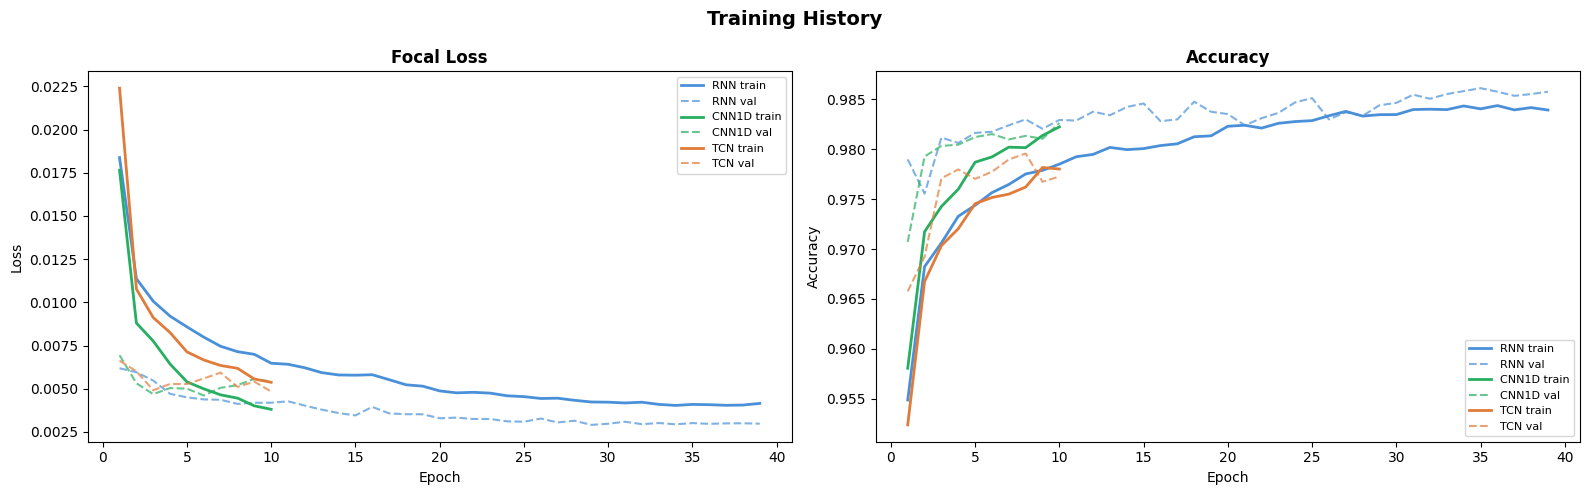

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

for name, hist in histories.items():
    color = MODEL_COLORS[name]
    ep    = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(ep, hist.history['loss'],     color=color, lw=2,   label=f'{name} train')
    axes[0].plot(ep, hist.history['val_loss'], color=color, lw=1.5, ls='--', alpha=0.7, label=f'{name} val')
    axes[1].plot(ep, hist.history['acc'],     color=color, lw=2,   label=f'{name} train')
    axes[1].plot(ep, hist.history['val_acc'], color=color, lw=1.5, ls='--', alpha=0.7, label=f'{name} val')

axes[0].set_title('Focal Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Threshold Tuning (Fire & Nuisance recall)

In [17]:
FIRE_IDX     = CLASS_NAMES.index('Fire')       # usually 1
NUISANCE_IDX = CLASS_NAMES.index('Nuisance')   # usually 2
BG_IDX       = CLASS_NAMES.index('Background') # usually 0


def tune_thresholds(
    model,
    X_val: np.ndarray,
    y_val: np.ndarray,
    fire_recall_target: float = 0.85,
    nuisance_recall_target: float = 0.80,
) -> dict:
    """Grid-search θ_fire and θ_nuisance on the validation set.

    Decision rule:
        if P(fire)     >= θ_fire     → Fire
        elif P(nuisance) >= θ_nuis   → Nuisance
        else                         → Background
    """
    probs  = model.predict(X_val, verbose=0)   # (N, 3)
    p_fire = probs[:, FIRE_IDX]
    p_nuis = probs[:, NUISANCE_IDX]

    best = {'score': -1, 'theta_fire': 0.5, 'theta_nuis': 0.5}
    rows = []

    for tf_ in np.arange(0.15, 0.81, 0.05):
        for tn in np.arange(0.15, 0.81, 0.05):
            pred = np.full(len(y_val), BG_IDX, dtype=int)
            pred[p_fire >= tf_] = FIRE_IDX
            pred[(p_fire < tf_) & (p_nuis >= tn)] = NUISANCE_IDX

            rec_f  = recall_score(y_val, pred, labels=[FIRE_IDX],     average='macro', zero_division=0)
            rec_n  = recall_score(y_val, pred, labels=[NUISANCE_IDX], average='macro', zero_division=0)
            f1_mac = f1_score(y_val, pred, average='macro', zero_division=0)

            # Composite: fire recall + nuisance recall + overall F1
            score = rec_f * 0.45 + rec_n * 0.35 + f1_mac * 0.20
            rows.append({'theta_fire': tf_, 'theta_nuis': tn,
                         'recall_fire': rec_f, 'recall_nuisance': rec_n,
                         'f1_macro': f1_mac, 'score': score})

            if (rec_f >= fire_recall_target
                    and rec_n >= nuisance_recall_target
                    and score > best['score']):
                best = {'score': score, 'theta_fire': tf_, 'theta_nuis': tn,
                        'recall_fire': rec_f, 'recall_nuisance': rec_n}

    return best, pd.DataFrame(rows)


best_thresholds = {}
for name, model in models.items():
    best, _ = tune_thresholds(model, X_val, y_val)
    best_thresholds[name] = best
    print(
        f'{name}: θ_fire={best["theta_fire"]:.2f}  '
        f'θ_nuis={best["theta_nuis"]:.2f}  '
        f'recall_fire={best.get("recall_fire", 0):.3f}  '
        f'recall_nuis={best.get("recall_nuisance", 0):.3f}'
    )

RNN: θ_fire=0.40  θ_nuis=0.35  recall_fire=0.986  recall_nuis=0.987
CNN1D: θ_fire=0.35  θ_nuis=0.40  recall_fire=0.990  recall_nuis=0.965
TCN: θ_fire=0.35  θ_nuis=0.35  recall_fire=0.988  recall_nuis=0.976


## 12. Predict on Test Set

In [18]:
def predict_with_thresholds(
    model,
    X: np.ndarray,
    theta_fire: float,
    theta_nuis: float,
) -> tuple[np.ndarray, np.ndarray]:
    probs  = model.predict(X, verbose=0)
    pred   = np.full(len(X), BG_IDX, dtype=int)
    pred[probs[:, FIRE_IDX] >= theta_fire] = FIRE_IDX
    mask   = (probs[:, FIRE_IDX] < theta_fire) & (probs[:, NUISANCE_IDX] >= theta_nuis)
    pred[mask] = NUISANCE_IDX
    return pred, probs


test_preds = {}
test_probs = {}
for name, model in models.items():
    tf_ = best_thresholds[name]['theta_fire']
    tn  = best_thresholds[name]['theta_nuis']
    pred, probs = predict_with_thresholds(model, X_test, tf_, tn)
    test_preds[name] = pred
    test_probs[name] = probs
    print(f'{name}: done')

RNN: done
CNN1D: done
TCN: done


## 13. Evaluation — Classification Reports

In [19]:
for name in models:
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(classification_report(
        y_test,
        test_preds[name],
        target_names=CLASS_NAMES,
        digits=4,
    ))

  RNN
              precision    recall  f1-score   support

  Background     0.9953    0.9593    0.9769     14069
        Fire     0.8477    0.9830    0.9103      2117
    Nuisance     0.7844    0.9628    0.8645       752

    accuracy                         0.9624     16938
   macro avg     0.8758    0.9683    0.9172     16938
weighted avg     0.9675    0.9624    0.9636     16938

  CNN1D
              precision    recall  f1-score   support

  Background     0.9922    0.9414    0.9662     14069
        Fire     0.7494    0.9787    0.8488      2117
    Nuisance     0.8410    0.9215    0.8794       752

    accuracy                         0.9452     16938
   macro avg     0.8609    0.9472    0.8981     16938
weighted avg     0.9551    0.9452    0.9476     16938

  TCN
              precision    recall  f1-score   support

  Background     0.9930    0.9271    0.9589     14069
        Fire     0.7375    0.9821    0.8424      2117
    Nuisance     0.7101    0.9282    0.8046       752



In [20]:
# ── Summary comparison table ──
rows = []
for name in models:
    yp = test_preds[name]
    rows.append({
        'Model':            name,
        'Accuracy':         round((yp == y_test).mean(), 4),
        'F1_macro':         round(f1_score(y_test, yp, average='macro',      zero_division=0), 4),
        'F1_weighted':      round(f1_score(y_test, yp, average='weighted',   zero_division=0), 4),
        'Recall_Fire':      round(recall_score(y_test, yp,    labels=[FIRE_IDX],     average='macro', zero_division=0), 4),
        'Precision_Fire':   round(precision_score(y_test, yp, labels=[FIRE_IDX],     average='macro', zero_division=0), 4),
        'F1_Fire':          round(f1_score(y_test, yp,        labels=[FIRE_IDX],     average='macro', zero_division=0), 4),
        'Recall_Nuisance':  round(recall_score(y_test, yp,    labels=[NUISANCE_IDX], average='macro', zero_division=0), 4),
        'F1_Nuisance':      round(f1_score(y_test, yp,        labels=[NUISANCE_IDX], average='macro', zero_division=0), 4),
        'Params':           models[name].count_params(),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
display(
    summary_df.style
    .highlight_max(
        subset=['Accuracy','F1_macro','Recall_Fire','F1_Fire','Recall_Nuisance','F1_Nuisance'],
        color='#d4f1d4',
    )
    .format({'Params': '{:,}'})
)

,Accuracy,F1_macro,F1_weighted,Recall_Fire,Precision_Fire,F1_Fire,Recall_Nuisance,F1_Nuisance,Params
Model,,,,,,,,,
RNN,0.962400,0.917200,0.963600,0.983000,0.847700,0.910300,0.962800,0.864500,"71,667"
CNN1D,0.945200,0.898100,0.947600,0.978700,0.749400,0.848800,0.921500,0.879400,"100,339"
TCN,0.934100,0.868600,0.937500,0.982100,0.737500,0.842400,0.928200,0.804600,"99,251"


## 14. Confusion Matrices

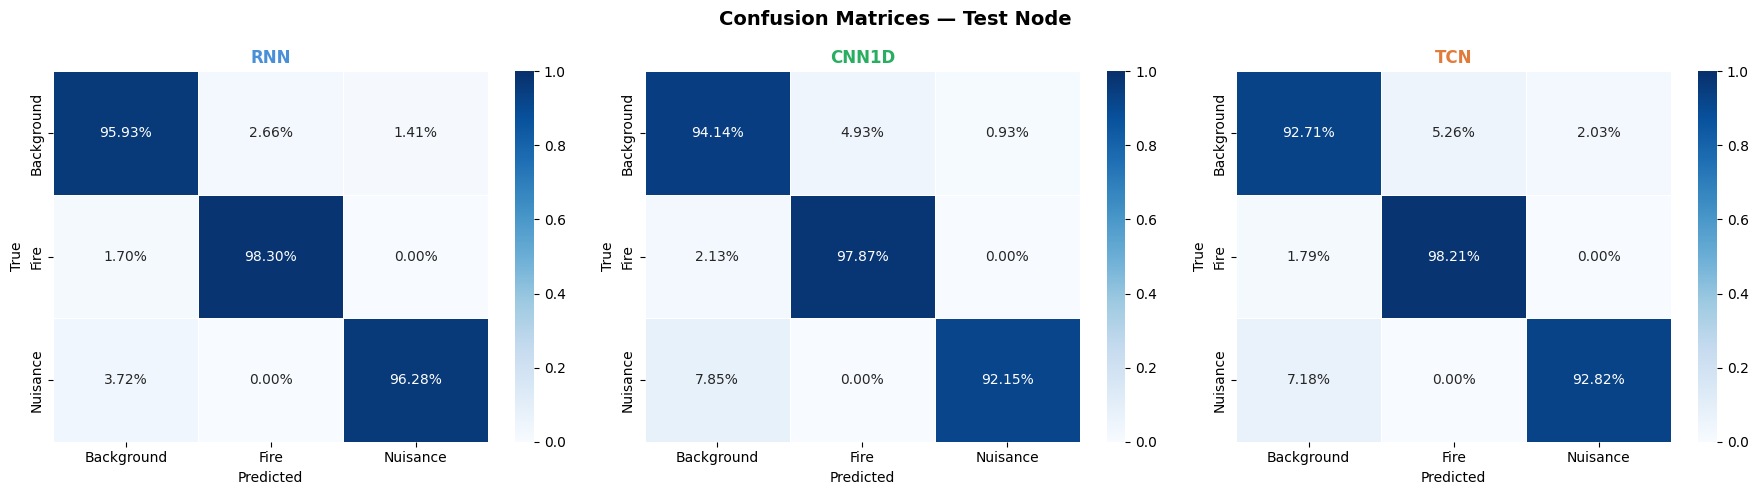

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Node', fontsize=14, fontweight='bold')

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, test_preds[name], normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, vmin=0, vmax=1,
    )
    ax.set_title(name, fontweight='bold', color=MODEL_COLORS[name], fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

## 15. Metric Bar Charts

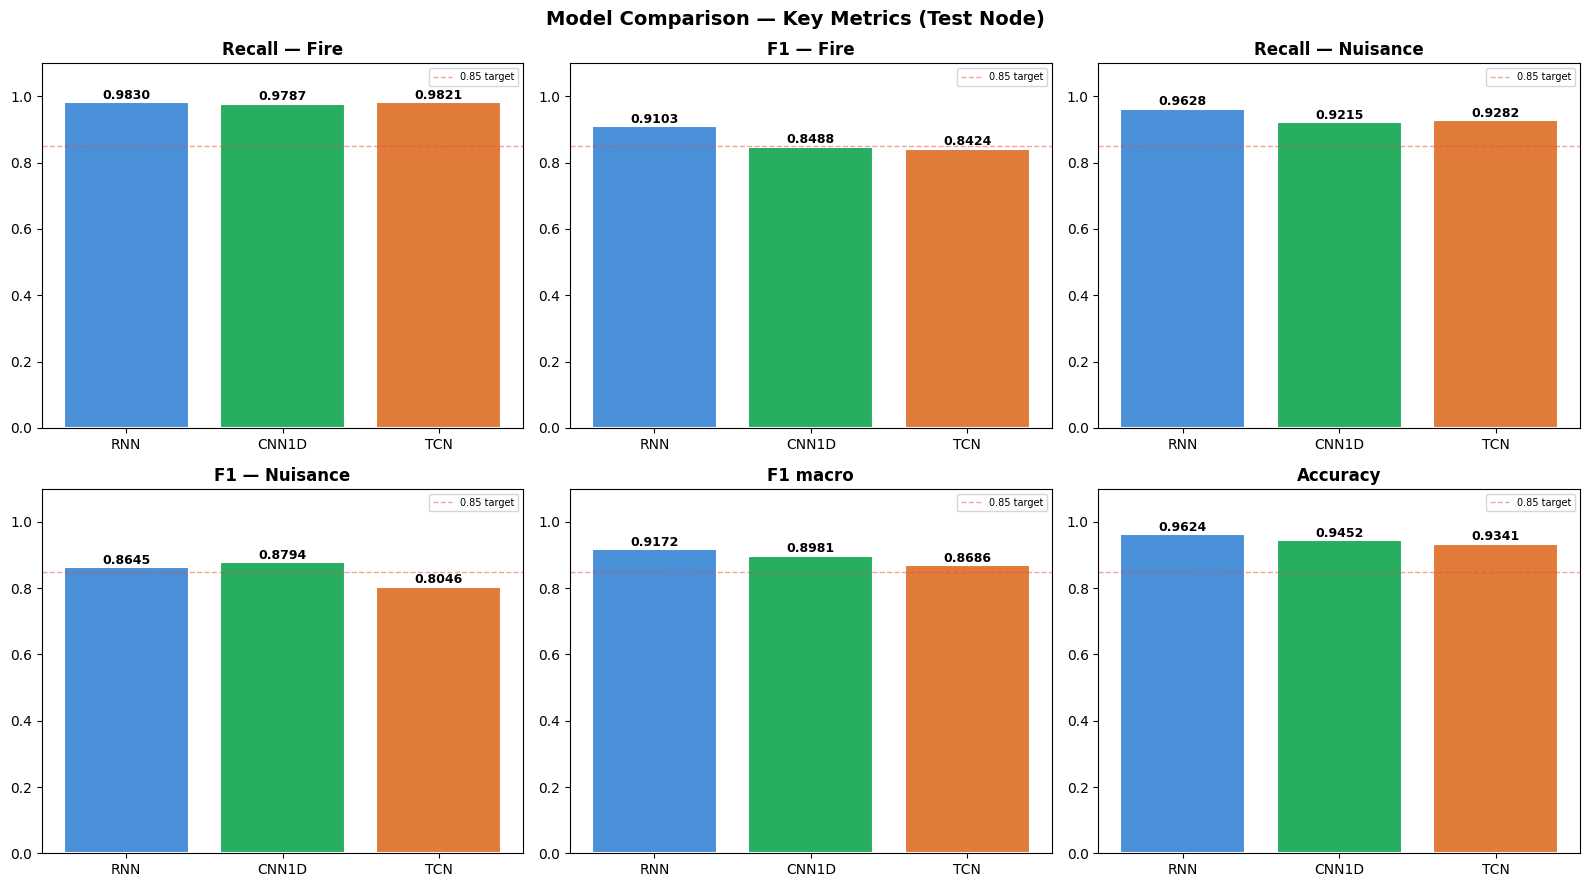

In [22]:
metrics_to_plot = [
    ('Recall_Fire',      'Recall — Fire'),
    ('F1_Fire',          'F1 — Fire'),
    ('Recall_Nuisance',  'Recall — Nuisance'),
    ('F1_Nuisance',      'F1 — Nuisance'),
    ('F1_macro',         'F1 macro'),
    ('Accuracy',         'Accuracy'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Model Comparison — Key Metrics (Test Node)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics_to_plot):
    vals = [summary_df.loc[m, col] for m in models]
    bars = ax.bar(
        list(models.keys()), vals,
        color=[MODEL_COLORS[m] for m in models],
        edgecolor='white', linewidth=1.5,
    )
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.85, color='#E74C3C', lw=1, ls='--', alpha=0.5, label='0.85 target')
    ax.legend(fontsize=7)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold',
        )

plt.tight_layout()
plt.show()

## 16. Precision-Recall Curves

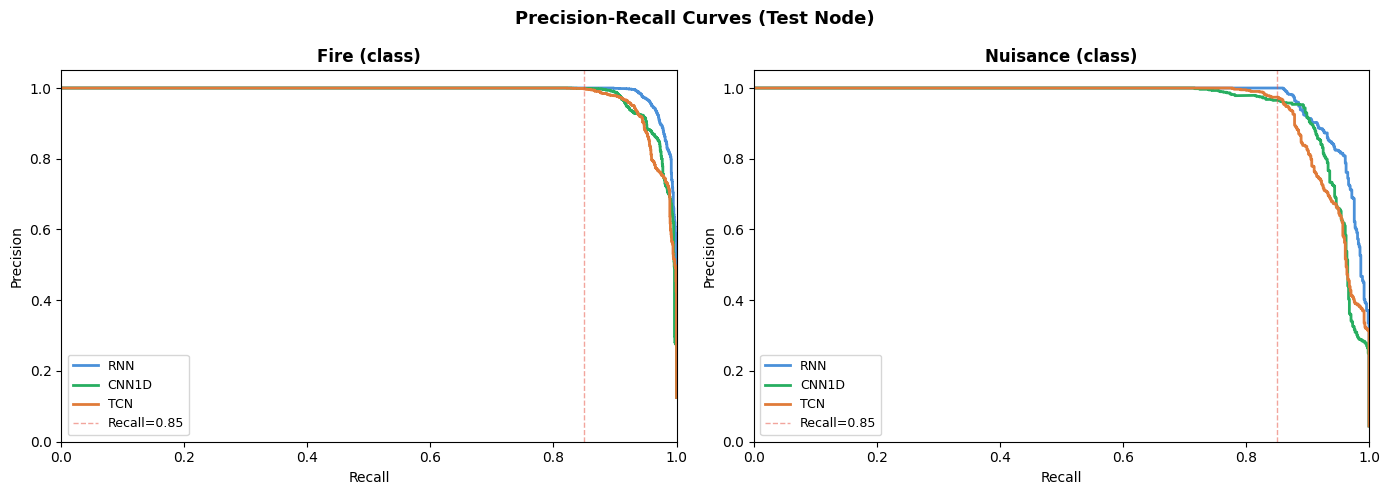

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision-Recall Curves (Test Node)', fontsize=13, fontweight='bold')

y_fire_bin    = (y_test == FIRE_IDX).astype(int)
y_nuisance_bin = (y_test == NUISANCE_IDX).astype(int)

for name, color in MODEL_COLORS.items():
    p_fire = test_probs[name][:, FIRE_IDX]
    p_nuis = test_probs[name][:, NUISANCE_IDX]

    prec_f, rec_f, _ = precision_recall_curve(y_fire_bin, p_fire)
    prec_n, rec_n, _ = precision_recall_curve(y_nuisance_bin, p_nuis)

    axes[0].plot(rec_f, prec_f, color=color, lw=2, label=name)
    axes[1].plot(rec_n, prec_n, color=color, lw=2, label=name)

for ax, title in zip(axes, ['Fire (class)', 'Nuisance (class)']):
    ax.axvline(0.85, color='#E74C3C', lw=1, ls='--', alpha=0.5, label='Recall=0.85')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 17. Temporal Prediction Plot

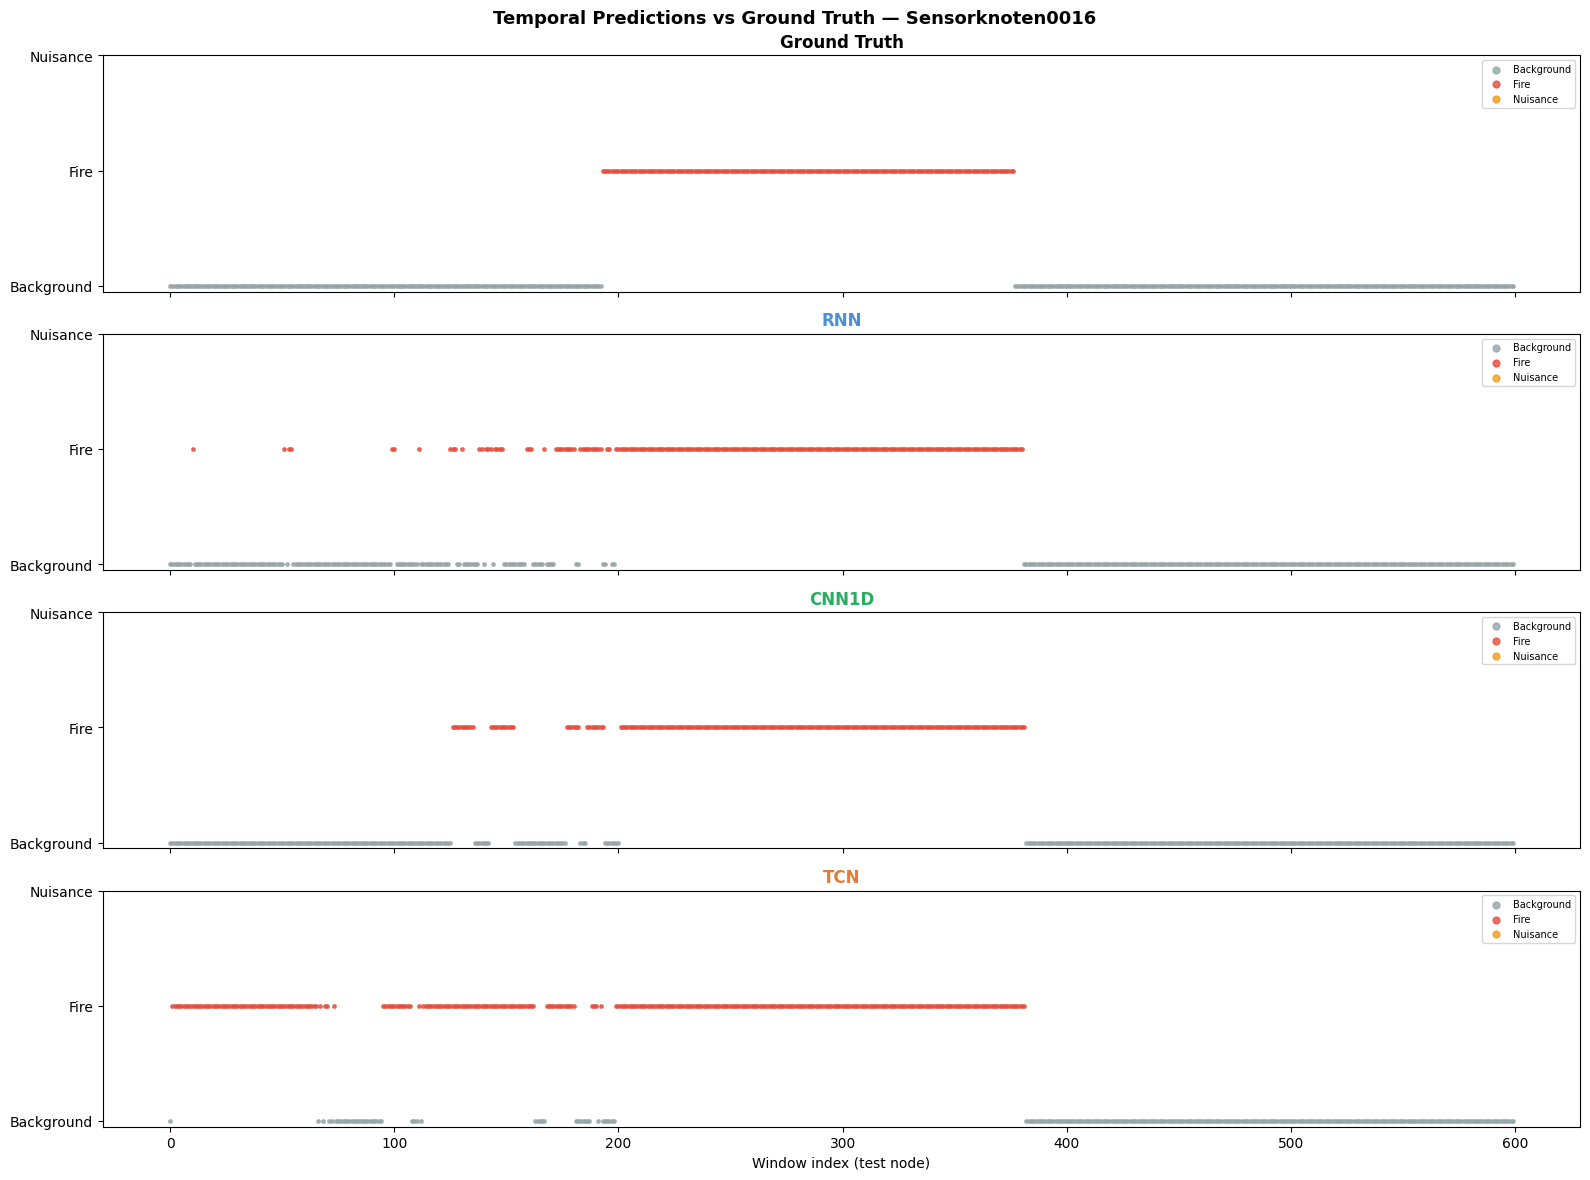

In [24]:
SEG   = slice(0, 600)   # first 600 windows of test node
t_idx = np.arange(SEG.start or 0, min(SEG.stop, len(y_test)))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    f'Temporal Predictions vs Ground Truth — {TEST_NODE}',
    fontsize=13, fontweight='bold',
)

label_colors_idx = {
    BG_IDX: '#95A5A6',
    FIRE_IDX: '#E74C3C',
    NUISANCE_IDX: '#F39C12',
}

def scatter_labels(ax, indices, labels, title, color_map):
    for cls, color in color_map.items():
        mask = labels[indices] == cls
        ax.scatter(
            indices[mask], np.full(mask.sum(), cls),
            c=color, s=6, alpha=0.8, label=CLASS_NAMES[cls],
        )
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')


scatter_labels(axes[0], t_idx, y_test, 'Ground Truth', label_colors_idx)
for ax, name in zip(axes[1:], models):
    scatter_labels(ax, t_idx, test_preds[name], name, label_colors_idx)
    ax.set_title(name, fontweight='bold', color=MODEL_COLORS[name])

axes[-1].set_xlabel('Window index (test node)')
plt.tight_layout()
plt.show()

## 18. Post-processing — Temporal Smoothing

In [25]:
def temporal_smooth(
    preds: np.ndarray,
    confirm_window: int = 3,
    bg_class: int = BG_IDX,
) -> np.ndarray:
    """Only emit a non-background alert after `confirm_window` consecutive predictions."""
    smoothed = preds.copy()
    count, current = 0, bg_class
    for i in range(len(smoothed)):
        if preds[i] == current:
            count += 1
        else:
            current, count = preds[i], 1
        if preds[i] != bg_class and count < confirm_window:
            smoothed[i] = bg_class
    return smoothed


print(f'Metrics after temporal smoothing (confirm_window=3):\n')
header = f'{"Model":<8} {"Rec_Fire":>10} {"F1_Fire":>8} {"Rec_Nuis":>10} {"F1_Nuis":>8} {"F1_mac":>8}'
print(header)
print('-' * len(header))

smooth_preds = {}
for name in models:
    sp = temporal_smooth(test_preds[name], confirm_window=3)
    smooth_preds[name] = sp
    rf  = recall_score(y_test,    sp, labels=[FIRE_IDX],     average='macro', zero_division=0)
    ff  = f1_score(y_test,        sp, labels=[FIRE_IDX],     average='macro', zero_division=0)
    rn  = recall_score(y_test,    sp, labels=[NUISANCE_IDX], average='macro', zero_division=0)
    fn  = f1_score(y_test,        sp, labels=[NUISANCE_IDX], average='macro', zero_division=0)
    fm  = f1_score(y_test,        sp, average='macro',                         zero_division=0)
    print(f'{name:<8} {rf:>10.4f} {ff:>8.4f} {rn:>10.4f} {fn:>8.4f} {fm:>8.4f}')

Metrics after temporal smoothing (confirm_window=3):

Model      Rec_Fire  F1_Fire   Rec_Nuis  F1_Nuis   F1_mac
---------------------------------------------------------
RNN          0.9721   0.9237     0.9521   0.8668   0.9235
CNN1D        0.9721   0.8573     0.9029   0.8801   0.9019
TCN          0.9717   0.8477     0.9122   0.8172   0.8755


## 19. Per-Scenario Breakdown

In [29]:
# Align scenario labels to test windows.
# make_windows labels each window by its LAST timestep and advances by STRIDE,
# so we must apply the same offset and stride here to stay in sync with y_test.
test_scenario = test_df['scenario_label'].values[WINDOW_SIZE - 1 :: STRIDE]

print('Per-scenario Recall (Fire / Nuisance) — Test node')
fire_scenarios     = ['Cable', 'Candles', 'Lunts', 'Wood']
nuisance_scenarios = ['Ethanol', 'Deodorant', 'Hairspray']

for name in models:
    print(f'\n── {name} ──')
    yp = test_preds[name]
    for sc in fire_scenarios + nuisance_scenarios:
        mask = test_scenario == sc
        if mask.sum() == 0:
            continue
        true_cls = FIRE_IDX if sc in fire_scenarios else NUISANCE_IDX
        rec = recall_score(
            y_test[mask], yp[mask],
            labels=[true_cls], average='macro', zero_division=0,
        )
        n = mask.sum()
        tag = 'Fire' if sc in fire_scenarios else 'Nuisance'
        print(f'  {sc:<12} ({tag:<8}, n={n:>5}): recall={rec:.3f}')

Per-scenario Recall (Fire / Nuisance) — Test node

── RNN ──
  Cable        (Fire    , n=  592): recall=0.985
  Candles      (Fire    , n=  481): recall=0.998
  Lunts        (Fire    , n=  532): recall=0.968
  Wood         (Fire    , n=  512): recall=0.982
  Ethanol      (Nuisance, n=  506): recall=0.962
  Deodorant    (Nuisance, n=  158): recall=0.975
  Hairspray    (Nuisance, n=   88): recall=0.943

── CNN1D ──
  Cable        (Fire    , n=  592): recall=0.968
  Candles      (Fire    , n=  481): recall=0.994
  Lunts        (Fire    , n=  532): recall=0.970
  Wood         (Fire    , n=  512): recall=0.986
  Ethanol      (Nuisance, n=  506): recall=0.929
  Deodorant    (Nuisance, n=  158): recall=0.911
  Hairspray    (Nuisance, n=   88): recall=0.898

── TCN ──
  Cable        (Fire    , n=  592): recall=0.988
  Candles      (Fire    , n=  481): recall=0.988
  Lunts        (Fire    , n=  532): recall=0.964
  Wood         (Fire    , n=  512): recall=0.988
  Ethanol      (Nuisance, n=  506

## 20. Final Summary & Model Selection

In [30]:
print('=' * 60)
print('FINAL COMPARISON (Test Node — after threshold tuning)')
print('=' * 60)

display(
    summary_df[[
        'Recall_Fire', 'F1_Fire',
        'Recall_Nuisance', 'F1_Nuisance',
        'F1_macro', 'Accuracy', 'Params',
    ]]
    .style
    .highlight_max(
        subset=['Recall_Fire','F1_Fire','Recall_Nuisance','F1_Nuisance','F1_macro','Accuracy'],
        color='#d4f1d4',
    )
    .format({'Params': '{:,}'})
)

best_fire    = summary_df['Recall_Fire'].idxmax()
best_overall = summary_df['F1_macro'].idxmax()
print(f'\n→ Best Fire recall   : {best_fire}')
print(f'→ Best overall F1    : {best_overall}')
print()
print('Sensor coverage with current hardware (DHT22 + MQ2):')
print('  Humidity, Temperature, H2/smoke proxy covered.')
print('  Missing: PM sensor (critical), VOC sensor, CO sensor.')
print('  Recommended purchase: PMS5003 + SGP30 + MQ7 (~$35 total)')

FINAL COMPARISON (Test Node — after threshold tuning)


,Recall_Fire,F1_Fire,Recall_Nuisance,F1_Nuisance,F1_macro,Accuracy,Params
Model,,,,,,,
RNN,0.983000,0.910300,0.962800,0.864500,0.917200,0.962400,"71,667"
CNN1D,0.978700,0.848800,0.921500,0.879400,0.898100,0.945200,"100,339"
TCN,0.982100,0.842400,0.928200,0.804600,0.868600,0.934100,"99,251"



→ Best Fire recall   : RNN
→ Best overall F1    : RNN

Sensor coverage with current hardware (DHT22 + MQ2):
  Humidity, Temperature, H2/smoke proxy covered.
  Missing: PM sensor (critical), VOC sensor, CO sensor.
  Recommended purchase: PMS5003 + SGP30 + MQ7 (~$35 total)


## 21. Save Models & Artifacts

In [31]:
import joblib

os.makedirs('saved_models', exist_ok=True)

for name, model in models.items():
    path = f'saved_models/{name.lower()}_indoor.keras'
    model.save(path)
    print(f'Saved {name} → {path}')

joblib.dump(scaler,           'saved_models/scaler_indoor.pkl')
joblib.dump(le,               'saved_models/label_encoder_indoor.pkl')
joblib.dump(best_thresholds,  'saved_models/thresholds_indoor.pkl')
joblib.dump(FEATURE_COLS,     'saved_models/feature_cols_indoor.pkl')

print('\nScaler, LabelEncoder, thresholds, feature list saved.')
print(f'FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Saved RNN → saved_models/rnn_indoor.keras
Saved CNN1D → saved_models/cnn1d_indoor.keras
Saved TCN → saved_models/tcn_indoor.keras

Scaler, LabelEncoder, thresholds, feature list saved.
FEATURE_COLS (28): ['CO_Room', 'H2_Room', 'Humidity_Room', 'PM05_Room', 'PM10_Room', 'PM_Room_Typical_Size', 'PM_Total_Room', 'Temperature_Room', 'UV_Room', 'VOC_Room_RAW', 'delta_CO_Room', 'delta_H2_Room', 'delta_PM05_Room', 'delta_PM_Total_Room', 'delta_VOC_Room_RAW', 'roll_mean_CO_Room', 'roll_mean_H2_Room', 'roll_mean_PM05_Room', 'roll_mean_PM_Total_Room', 'roll_mean_VOC_Room_RAW', 'roll_std_CO_Room', 'roll_std_H2_Room', 'roll_std_PM05_Room', 'roll_std_PM_Total_Room', 'roll_std_VOC_Room_RAW', 'VOC_CO_ratio', 'PM_size_ratio', 'UV_norm']


## 3. Streaming Simulation Utilities

In [32]:
## 3. Streaming Simulation Utilities
def add_gaussian_noise(X: np.ndarray, noise_pct: float, seed: int = 42) -> np.ndarray:
    """Add Gaussian noise scaled to each feature's std.

    noise_pct=0.05 → noise std = 5 % of each feature's std across the batch.
    Mirrors real sensor noise from vibration, EMI, humidity effects.
    """
    rng      = np.random.default_rng(seed)
    feat_std = X.reshape(-1, X.shape[-1]).std(axis=0, keepdims=True)  # (1, F)
    noise    = rng.normal(0, noise_pct * feat_std, size=X.shape)
    return (X + noise).astype(np.float32)


def apply_future_padding(
    X: np.ndarray,
    pad_steps: int,
    strategy: str = 'zero',
) -> np.ndarray:
    """Simulate streaming: the last `pad_steps` timesteps are not yet available.

    strategy:
      'zero'       — replace future steps with 0  (hard padding)
      'last_value' — repeat the last known value  (softer, common in practice)
      'mean'       — replace with per-feature mean of available steps
    """
    X_pad = X.copy()
    if pad_steps <= 0:
        return X_pad
    avail = X.shape[1] - pad_steps        # number of real steps available
    if strategy == 'zero':
        X_pad[:, avail:, :] = 0.0
    elif strategy == 'last_value':
        last = X[:, avail - 1:avail, :]   # (N, 1, F)
        X_pad[:, avail:, :] = np.repeat(last, pad_steps, axis=1)
    elif strategy == 'mean':
        means = X[:, :avail, :].mean(axis=1, keepdims=True)  # (N, 1, F)
        X_pad[:, avail:, :] = np.repeat(means, pad_steps, axis=1)
    return X_pad.astype(np.float32)


def predict_argmax(model, X):
    """Simple argmax — no threshold tuning for fair robustness comparison."""
    return np.argmax(model.predict(X, verbose=0), axis=1)

def compute_metrics(y_true, y_pred, name=''):
    return {
        'model':          name,
        'accuracy':       round((y_pred == y_true).mean(), 4),
        'f1_macro':       round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'recall_fire':    round(recall_score(y_true, y_pred, labels=[FIRE_IDX],     average='macro', zero_division=0), 4),
        'recall_nuis':    round(recall_score(y_true, y_pred, labels=[NUISANCE_IDX], average='macro', zero_division=0), 4),
        'f1_fire':        round(f1_score(y_true, y_pred, labels=[FIRE_IDX],         average='macro', zero_division=0), 4),
        'f1_nuis':        round(f1_score(y_true, y_pred, labels=[NUISANCE_IDX],     average='macro', zero_division=0), 4),
    }
    
baseline = {}
print('=== Baseline (clean test) ===')
for name, model in models.items():
    pred = predict_argmax(model, X_test)
    m    = compute_metrics(y_test, pred, name)
    baseline[name] = m
    print(f'{name}: acc={m["accuracy"]:.4f}  f1_macro={m["f1_macro"]:.4f}  '
          f'recall_fire={m["recall_fire"]:.4f}  recall_nuis={m["recall_nuis"]:.4f}')

baseline_df = pd.DataFrame(baseline.values()).set_index('model')
display(baseline_df)
def run_streaming_experiment(
    models: dict,
    X_test: np.ndarray,
    y_test: np.ndarray,
    noise_pct: float = 0.0,
    pad_steps: int   = 0,
    pad_strategy: str = 'zero',
    seed: int = 42,
) -> pd.DataFrame:
    """Apply noise + padding then collect metrics for each model."""
    X = X_test.copy()
    if noise_pct > 0:
        X = add_gaussian_noise(X, noise_pct, seed=seed)
    if pad_steps > 0:
        X = apply_future_padding(X, pad_steps, strategy=pad_strategy)

    rows = []
    for name, model in models.items():
        pred = predict_argmax(model, X)
        m    = compute_metrics(y_test, pred, name)
        m['noise_pct']    = noise_pct
        m['pad_steps']    = pad_steps
        m['pad_strategy'] = pad_strategy
        rows.append(m)
    return pd.DataFrame(rows).set_index('model')


print('Utilities ready.')

=== Baseline (clean test) ===
RNN: acc=0.9821  f1_macro=0.9526  recall_fire=0.9485  recall_nuis=0.9029
CNN1D: acc=0.9754  f1_macro=0.9429  recall_fire=0.9277  recall_nuis=0.8697
TCN: acc=0.9750  f1_macro=0.9394  recall_fire=0.9268  recall_nuis=0.8790


,accuracy,f1_macro,recall_fire,recall_nuis,f1_fire,f1_nuis
model,,,,,,
RNN,0.9821,0.9526,0.9485,0.9029,0.9603,0.9084
CNN1D,0.9754,0.9429,0.9277,0.8697,0.9308,0.9128
TCN,0.9750,0.9394,0.9268,0.8790,0.9350,0.8981


Utilities ready.


## 4. Test A — Gaussian Noise Sweep

In [33]:
NOISE_LEVELS = [0.0, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50]

noise_results = []    # list of DataFrames
for noise_pct in NOISE_LEVELS:
    df_r = run_streaming_experiment(models, X_test, y_test, noise_pct=noise_pct)
    df_r['noise_pct'] = noise_pct
    noise_results.append(df_r)
    print(f'noise={noise_pct*100:.0f}%: '
          + '  '.join(f'{n}: f1={noise_results[-1].loc[n, "f1_macro"]:.3f}' for n in models))

noise_df = pd.concat(noise_results)

noise=0%: RNN: f1=0.953  CNN1D: f1=0.943  TCN: f1=0.939
noise=2%: RNN: f1=0.952  CNN1D: f1=0.943  TCN: f1=0.939
noise=5%: RNN: f1=0.952  CNN1D: f1=0.943  TCN: f1=0.939
noise=10%: RNN: f1=0.950  CNN1D: f1=0.943  TCN: f1=0.939
noise=20%: RNN: f1=0.947  CNN1D: f1=0.941  TCN: f1=0.938
noise=35%: RNN: f1=0.934  CNN1D: f1=0.939  TCN: f1=0.937
noise=50%: RNN: f1=0.913  CNN1D: f1=0.932  TCN: f1=0.928


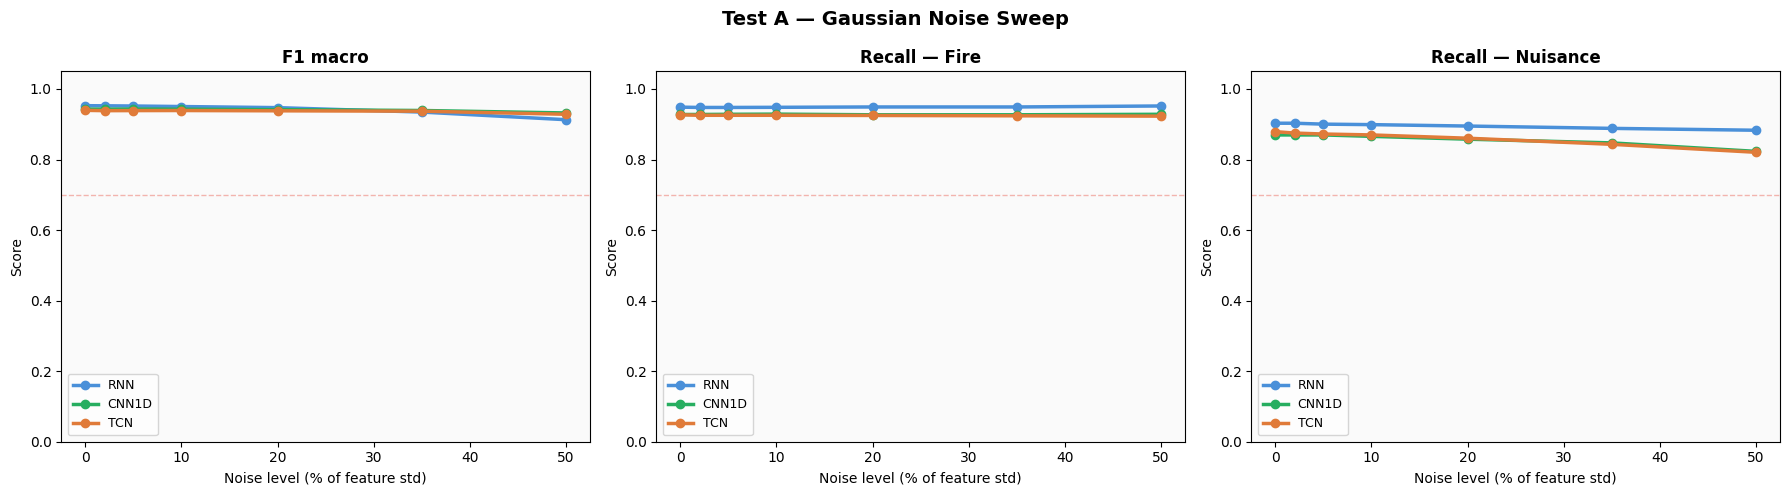

In [34]:
# ── Plot: F1-macro vs noise level ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test A — Gaussian Noise Sweep', fontsize=14, fontweight='bold')

metrics_plot = [
    ('f1_macro',    'F1 macro'),
    ('recall_fire', 'Recall — Fire'),
    ('recall_nuis', 'Recall — Nuisance'),
]

for ax, (metric, title) in zip(axes, metrics_plot):
    for name, color in MODEL_COLORS.items():
        vals = [noise_df.xs(name).query('noise_pct == @lvl')[metric].values[0]
                for lvl in NOISE_LEVELS]
        ax.plot([l * 100 for l in NOISE_LEVELS], vals,
                color=color, linewidth=2.5, marker='o', markersize=6, label=name)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Noise level (% of feature std)')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.axhline(0.7, color='#E74C3C', lw=1, ls='--', alpha=0.4, label='0.70 threshold')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

In [35]:
# Degradation table — how much each model drops vs baseline
print('=== F1-macro degradation vs baseline (noise sweep) ===')
print(f'{"Model":<8}', end='')
for lvl in NOISE_LEVELS:
    print(f'  {lvl*100:.0f}%', end='')
print()
for name in models:
    base_f1 = baseline[name]['f1_macro']
    print(f'{name:<8}', end='')
    for lvl in NOISE_LEVELS:
        f1 = noise_df.xs(name).query('noise_pct == @lvl')['f1_macro'].values[0]
        delta = f1 - base_f1
        print(f'  {delta:+.3f}', end='')
    print()

=== F1-macro degradation vs baseline (noise sweep) ===
Model     0%  2%  5%  10%  20%  35%  50%
RNN       +0.000  -0.000  -0.001  -0.002  -0.005  -0.018  -0.040
CNN1D     +0.000  -0.000  +0.000  -0.000  -0.002  -0.004  -0.011
TCN       +0.000  -0.001  -0.001  -0.001  -0.001  -0.002  -0.011


## 5. Test B — Future Padding Sweep (3 strategies)

In [36]:
PAD_STEPS    = [0, 2, 4, 6, 9, 12, 15, 17]    # steps missing (window=18)
PAD_STRATEGIES = ['zero', 'last_value', 'mean']

pad_results = {strat: [] for strat in PAD_STRATEGIES}

for strategy in PAD_STRATEGIES:
    print(f'Strategy: {strategy}')
    for ps in PAD_STEPS:
        df_r = run_streaming_experiment(models, X_test, y_test,
                                        pad_steps=ps, pad_strategy=strategy)
        df_r['pad_steps']    = ps
        df_r['pad_strategy'] = strategy
        pad_results[strategy].append(df_r)
    pad_results[strategy] = pd.concat(pad_results[strategy])
    print(f'  done.')

Strategy: zero
  done.
Strategy: last_value
  done.
Strategy: mean
  done.


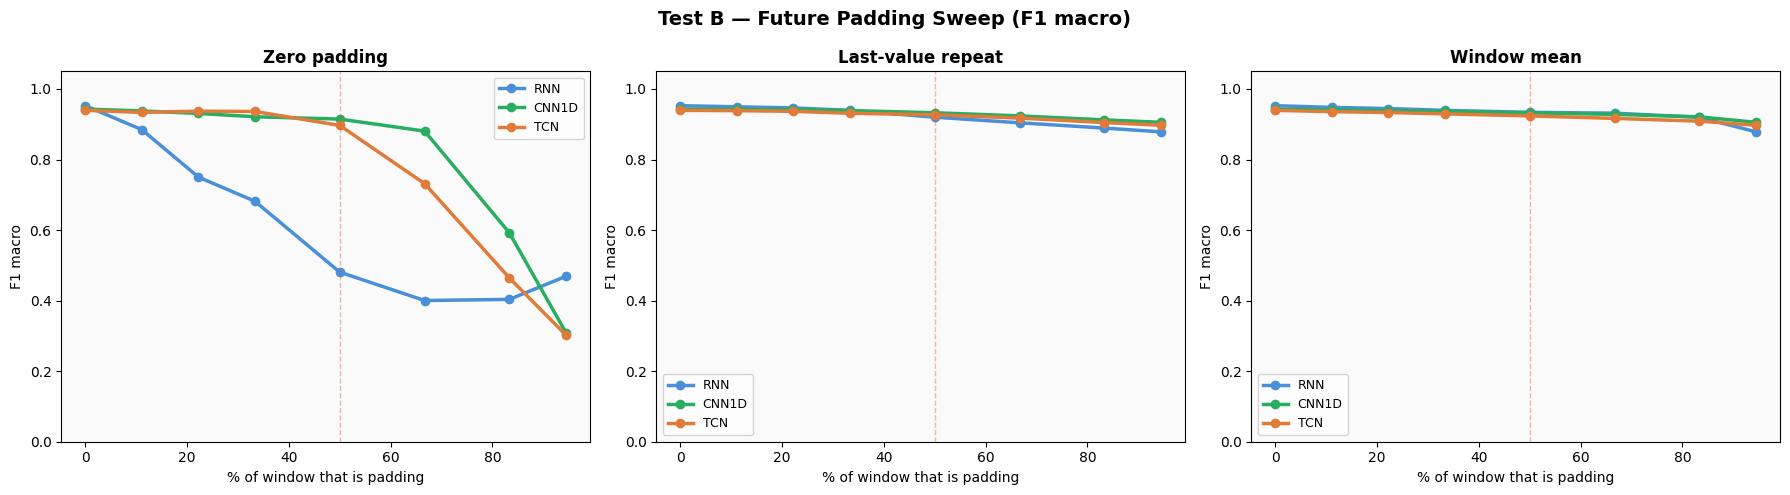

In [37]:
# ── Plot: F1-macro vs pad_steps for each strategy ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test B — Future Padding Sweep (F1 macro)', fontsize=14, fontweight='bold')

strat_labels = {'zero': 'Zero padding', 'last_value': 'Last-value repeat', 'mean': 'Window mean'}

for ax, strategy in zip(axes, PAD_STRATEGIES):
    df_s = pad_results[strategy]
    for name, color in MODEL_COLORS.items():
        vals = [df_s.xs(name).query('pad_steps == @ps')['f1_macro'].values[0]
                for ps in PAD_STEPS]
        pct  = [ps / WINDOW_SIZE * 100 for ps in PAD_STEPS]
        ax.plot(pct, vals, color=color, linewidth=2.5, marker='o', markersize=6, label=name)
    ax.set_title(strat_labels[strategy], fontweight='bold')
    ax.set_xlabel('% of window that is padding')
    ax.set_ylabel('F1 macro')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.axvline(50, color='#E74C3C', lw=1, ls='--', alpha=0.4, label='50% padded')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

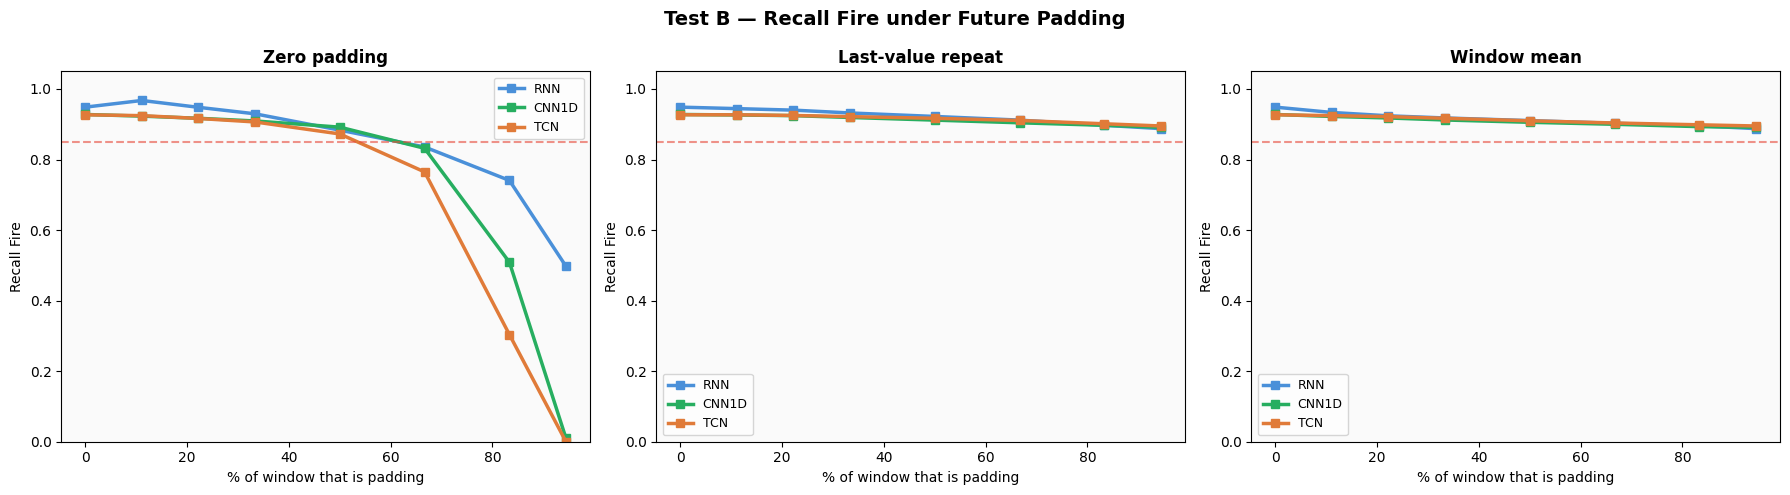

In [38]:
# Recall Fire under padding (most safety-critical metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Test B — Recall Fire under Future Padding', fontsize=14, fontweight='bold')

for ax, strategy in zip(axes, PAD_STRATEGIES):
    df_s = pad_results[strategy]
    for name, color in MODEL_COLORS.items():
        vals = [df_s.xs(name).query('pad_steps == @ps')['recall_fire'].values[0]
                for ps in PAD_STEPS]
        pct  = [ps / WINDOW_SIZE * 100 for ps in PAD_STEPS]
        ax.plot(pct, vals, color=color, linewidth=2.5, marker='s', markersize=6, label=name)
    ax.set_title(strat_labels[strategy], fontweight='bold')
    ax.set_xlabel('% of window that is padding')
    ax.set_ylabel('Recall Fire')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.axhline(0.85, color='#E74C3C', lw=1.5, ls='--', alpha=0.6, label='Target 0.85')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

In [39]:
# ── Break-even table: max pad_steps where recall_fire >= 0.85 ──
print('=== Max padding before Recall-Fire drops below 0.85 ===')
print(f'{"Model":<8}', end='')
for s in PAD_STRATEGIES:
    print(f'  {s:<14}', end='')
print()

for name in models:
    print(f'{name:<8}', end='')
    for strategy in PAD_STRATEGIES:
        df_s   = pad_results[strategy]
        max_ok = -1
        for ps in PAD_STEPS:
            rf = df_s.xs(name).query('pad_steps == @ps')['recall_fire'].values[0]
            if rf >= 0.85:
                max_ok = ps
        label = f'{max_ok}s ({max_ok/WINDOW_SIZE*100:.0f}%)' if max_ok >= 0 else 'NEVER'
        print(f'  {label:<14}', end='')
    print()

=== Max padding before Recall-Fire drops below 0.85 ===
Model     zero            last_value      mean          
RNN       9s (50%)        17s (94%)       17s (94%)     
CNN1D     9s (50%)        17s (94%)       17s (94%)     
TCN       9s (50%)        17s (94%)       17s (94%)     


## 6. Test C — Combined: Noise + Future Padding

In [40]:
# 2D grid: noise_pct × pad_steps  (strategy = 'last_value' as most realistic)
NOISE_GRID = [0.0, 0.05, 0.10, 0.20, 0.35]
PAD_GRID   = [0, 4, 9, 12, 15]
STRATEGY   = 'last_value'

combined_data = {name: np.zeros((len(NOISE_GRID), len(PAD_GRID))) for name in models}

for i, noise_pct in enumerate(NOISE_GRID):
    for j, pad_steps in enumerate(PAD_GRID):
        df_r = run_streaming_experiment(
            models, X_test, y_test,
            noise_pct=noise_pct, pad_steps=pad_steps,
            pad_strategy=STRATEGY,
        )
        for name in models:
            combined_data[name][i, j] = df_r.loc[name, 'recall_fire']
    print(f'noise={noise_pct*100:.0f}% done')

noise=0% done
noise=5% done
noise=10% done
noise=20% done
noise=35% done


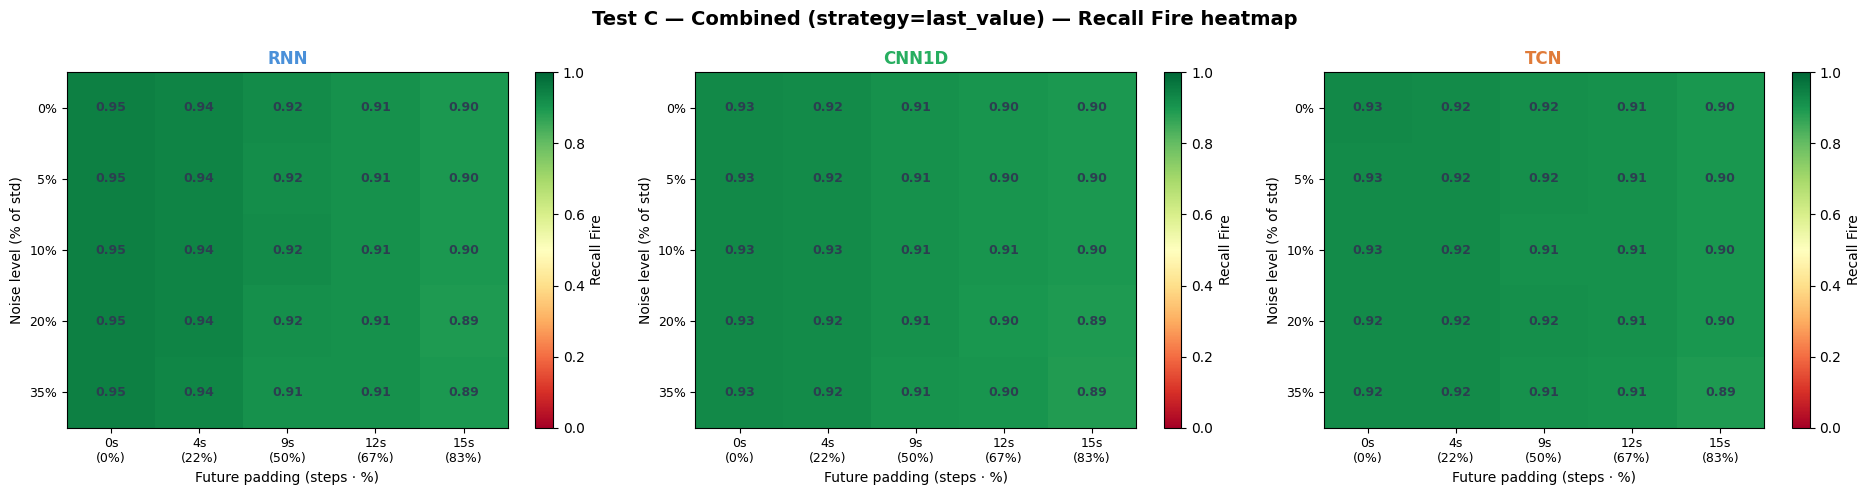

In [41]:
# ── Heatmaps: recall_fire across noise × pad grid ──
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(
    f'Test C — Combined (strategy={STRATEGY}) — Recall Fire heatmap',
    fontsize=14, fontweight='bold'
)

xlabels = [f'{ps}s\n({ps/WINDOW_SIZE*100:.0f}%)' for ps in PAD_GRID]
ylabels = [f'{n*100:.0f}%' for n in NOISE_GRID]

for ax, name in zip(axes, models):
    mat  = combined_data[name]
    im   = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(PAD_GRID)))
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_yticks(range(len(NOISE_GRID)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel('Future padding (steps · %)')
    ax.set_ylabel('Noise level (% of std)')
    ax.set_title(name, fontweight='bold', color=MODEL_COLORS[name], fontsize=12)
    plt.colorbar(im, ax=ax, label='Recall Fire')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i,j]:.2f}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if mat[i,j] < 0.5 else '#2C3E50')

plt.tight_layout()
plt.show()

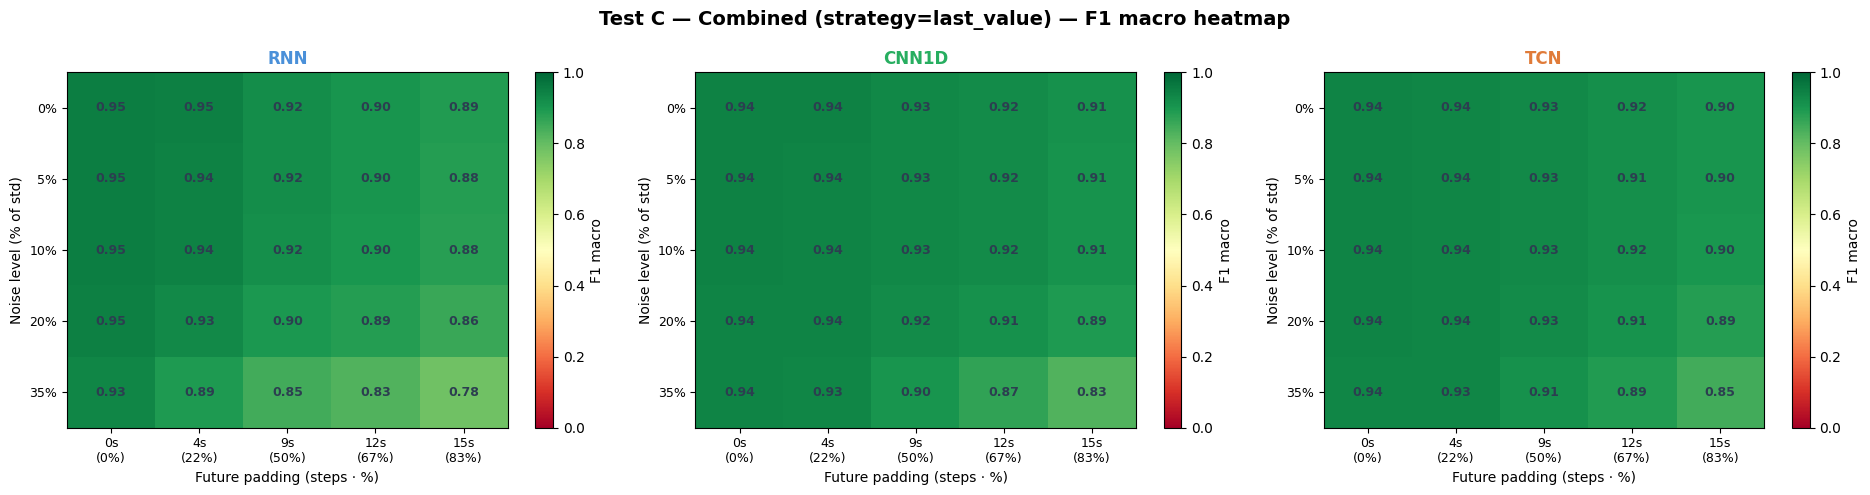

In [42]:
# Same but for F1-macro
combined_f1 = {name: np.zeros((len(NOISE_GRID), len(PAD_GRID))) for name in models}

for i, noise_pct in enumerate(NOISE_GRID):
    for j, pad_steps in enumerate(PAD_GRID):
        df_r = run_streaming_experiment(
            models, X_test, y_test,
            noise_pct=noise_pct, pad_steps=pad_steps,
            pad_strategy=STRATEGY,
        )
        for name in models:
            combined_f1[name][i, j] = df_r.loc[name, 'f1_macro']

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(
    f'Test C — Combined (strategy={STRATEGY}) — F1 macro heatmap',
    fontsize=14, fontweight='bold'
)

for ax, name in zip(axes, models):
    mat = combined_f1[name]
    im  = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(PAD_GRID)))
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_yticks(range(len(NOISE_GRID)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel('Future padding (steps · %)')
    ax.set_ylabel('Noise level (% of std)')
    ax.set_title(name, fontweight='bold', color=MODEL_COLORS[name], fontsize=12)
    plt.colorbar(im, ax=ax, label='F1 macro')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f'{mat[i,j]:.2f}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if mat[i,j] < 0.5 else '#2C3E50')

plt.tight_layout()
plt.show()

## 7. Test D — Confusion Matrix Shift under Stress

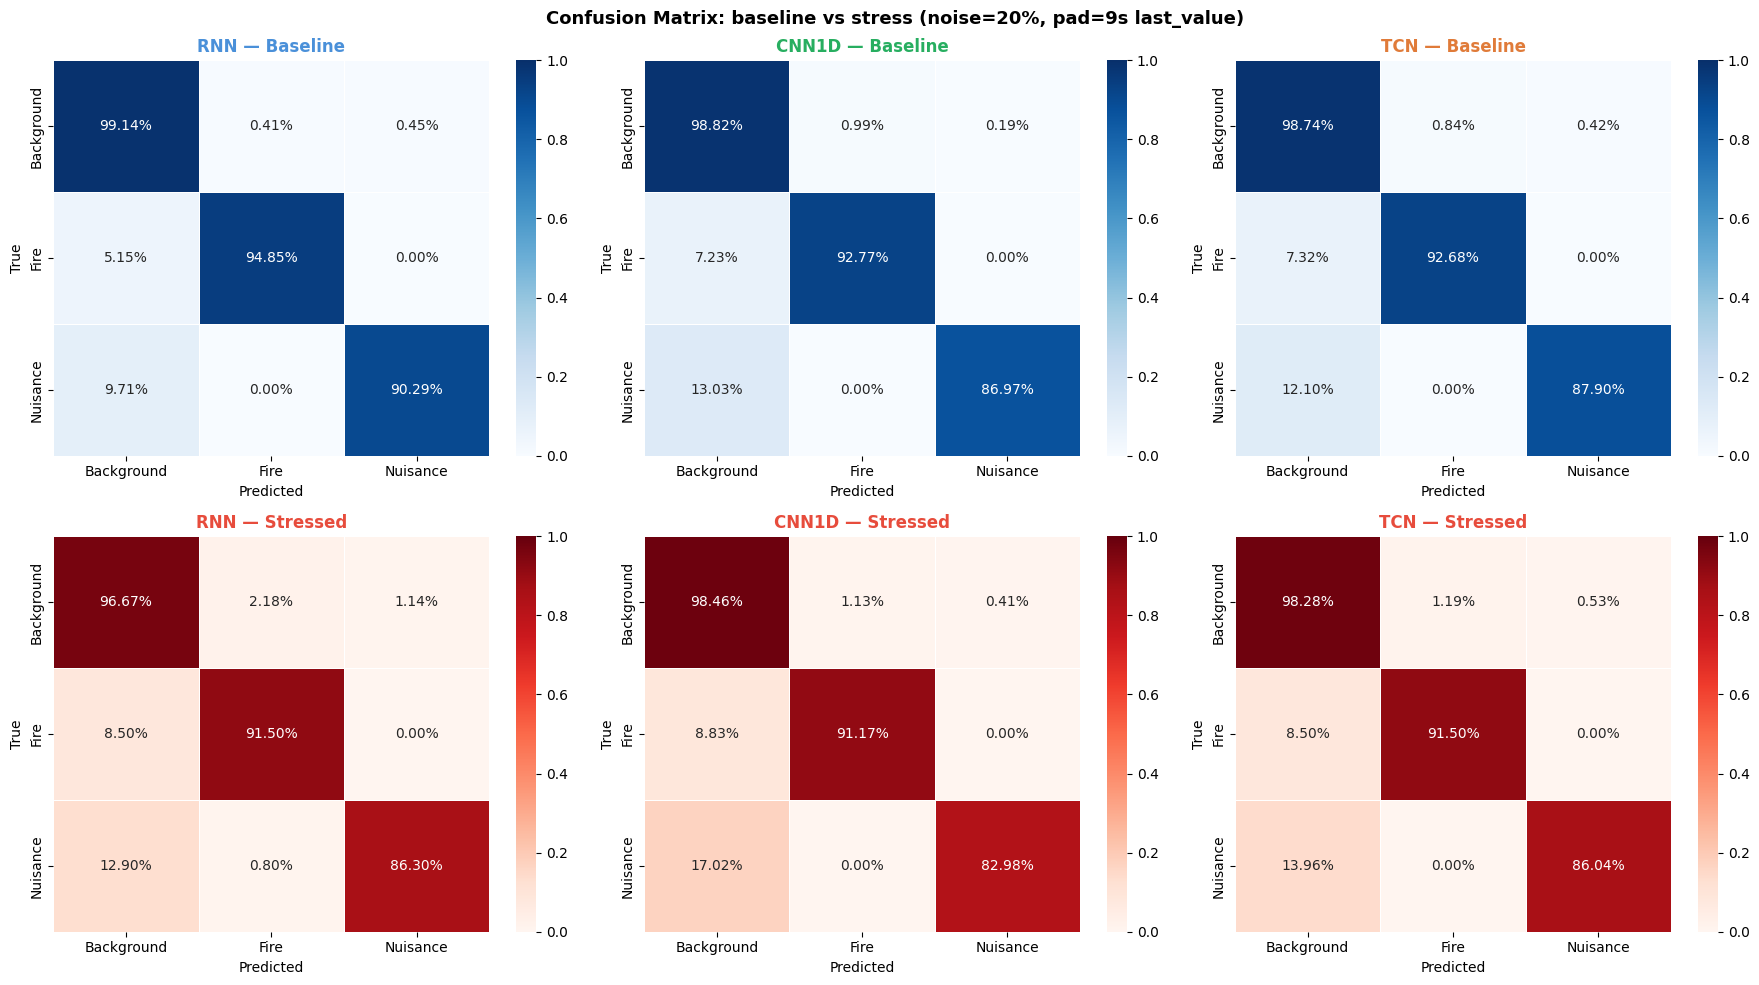

In [43]:
# Compare confusion matrices: baseline vs worst-case (noise=20% + pad=9 last_value)
STRESS_NOISE = 0.20
STRESS_PAD   = 9

X_stress = apply_future_padding(
    add_gaussian_noise(X_test, STRESS_NOISE),
    STRESS_PAD, strategy='last_value'
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'Confusion Matrix: baseline vs stress (noise={STRESS_NOISE*100:.0f}%, '
    f'pad={STRESS_PAD}s last_value)',
    fontsize=13, fontweight='bold'
)

for col_i, name in enumerate(models):
    model = models[name]

    # Row 0: baseline
    pred_clean = predict_argmax(model, X_test)
    cm_clean   = confusion_matrix(y_test, pred_clean, normalize='true')
    sns.heatmap(cm_clean, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0, col_i], linewidths=0.5, vmin=0, vmax=1)
    axes[0, col_i].set_title(f'{name} — Baseline', fontweight='bold',
                              color=MODEL_COLORS[name])
    axes[0, col_i].set_xlabel('Predicted')
    axes[0, col_i].set_ylabel('True')

    # Row 1: stressed
    pred_stress = predict_argmax(model, X_stress)
    cm_stress   = confusion_matrix(y_test, pred_stress, normalize='true')
    sns.heatmap(cm_stress, annot=True, fmt='.2%', cmap='Reds',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1, col_i], linewidths=0.5, vmin=0, vmax=1)
    axes[1, col_i].set_title(f'{name} — Stressed', fontweight='bold',
                              color='#E74C3C')
    axes[1, col_i].set_xlabel('Predicted')
    axes[1, col_i].set_ylabel('True')

plt.tight_layout()
plt.show()

## 8. Test E — Live Streaming Simulation (per-window)

In [ ]:
def simulate_streaming(
    model,
    X_raw_node: np.ndarray,
    y_node: np.ndarray,
    window: int,
    noise_pct: float = 0.05,
    latency_steps: int = 6,
    seed: int = 42,
) -> dict:
    """Simulate true online inference:
      - At step t, we have real data for steps [t-window+1 .. t-latency_steps]
      - Future `latency_steps` are padded with last-known value
      - Gaussian noise is added to all real steps

    Returns arrays of predictions and true labels.
    """
    rng = np.random.default_rng(seed)
    feat_std = X_raw_node.std(axis=0)

    preds, trues, probs_list = [], [], []

    for t in range(window - 1, len(X_raw_node)):
        # Real data slice (t-window+1 to t)
        real_slice = X_raw_node[t - window + 1 : t + 1].copy()   # (W, F)

        # Add noise to real steps
        noise = rng.normal(0, noise_pct * feat_std, size=real_slice.shape)
        real_slice = real_slice + noise

        # Simulate latency: last `latency_steps` repeated from last known
        avail = window - latency_steps
        last_known = real_slice[avail - 1]
        real_slice[avail:] = last_known

        window_input = real_slice[np.newaxis, :, :].astype(np.float32)  # (1, W, F)
        prob  = model.predict(window_input, verbose=0)[0]
        pred  = np.argmax(prob)

        preds.append(pred)
        trues.append(y_node[t])
        probs_list.append(prob)

    return {
        'preds':  np.array(preds),
        'trues':  np.array(trues),
        'probs':  np.array(probs_list),
    }


# Run on test node (use raw scaled data so features are consistent)
NOISE_STREAM   = 0.05
LATENCY_STREAM = 6          # 6 steps = 60-second sensor lag

stream_results = {}
for name, model in models.items():
    print(f'Simulating streaming for {name}...', end=' ', flush=True)
    res = simulate_streaming(
        model, X_test_raw, y_test_raw,
        window=WINDOW_SIZE,
        noise_pct=NOISE_STREAM,
        latency_steps=LATENCY_STREAM,
    )
    stream_results[name] = res
    m = compute_metrics(res['trues'], res['preds'], name)
    print(f'f1_macro={m["f1_macro"]:.4f}  recall_fire={m["recall_fire"]:.4f}')

Simulating streaming for RNN... f1_macro=0.9368  recall_fire=0.9309
Simulating streaming for CNN1D... 

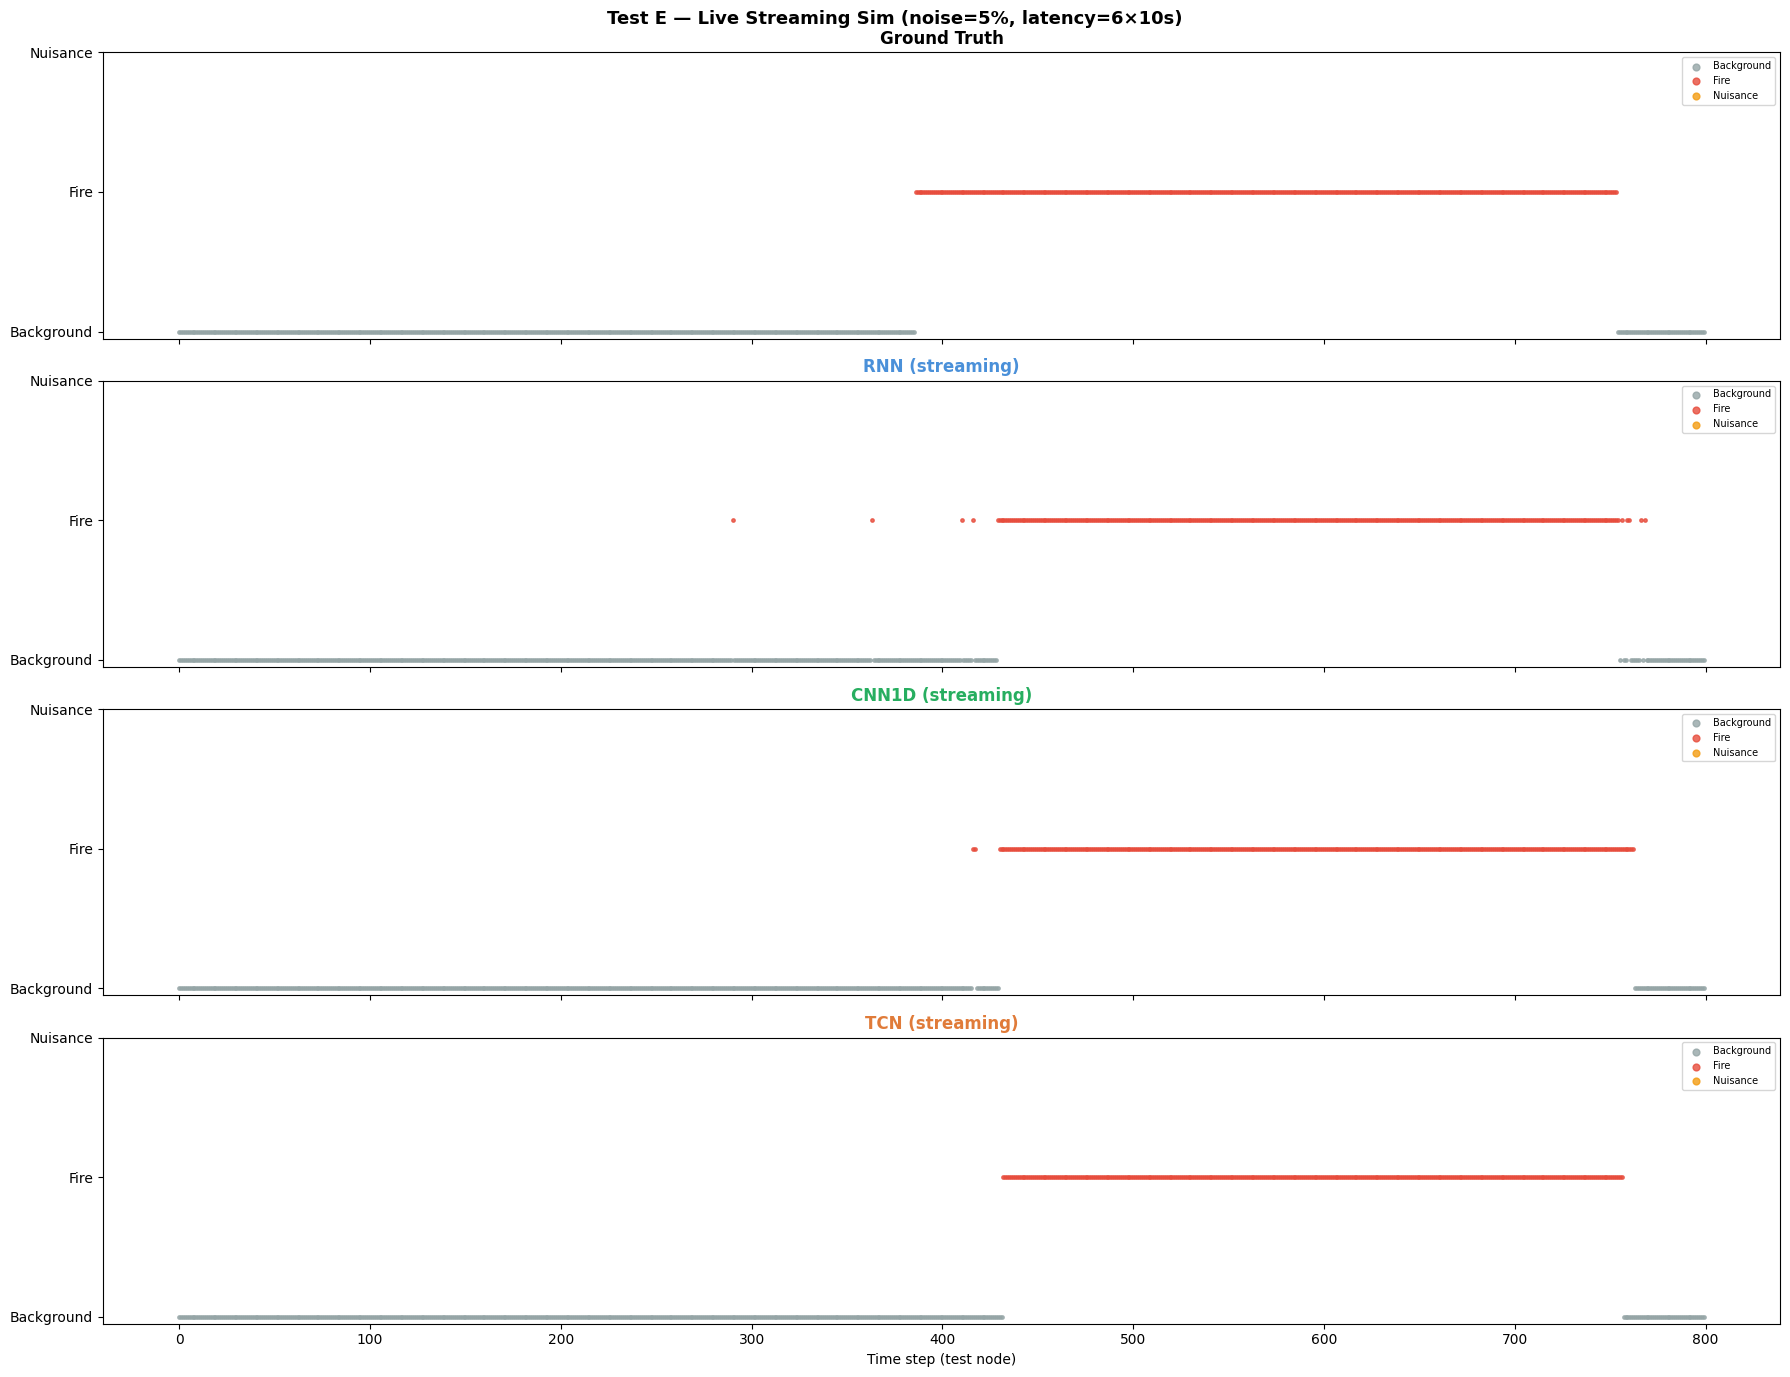

In [ ]:
# ── Plot streaming predictions vs ground truth ──
SEG = slice(0, 800)

label_colors_map = {0: '#95A5A6', 1: '#E74C3C', 2: '#F39C12'}

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle(
    f'Test E — Live Streaming Sim (noise={NOISE_STREAM*100:.0f}%, latency={LATENCY_STREAM}×10s)',
    fontsize=13, fontweight='bold'
)

ref = stream_results['RNN']
idx = np.arange(SEG.start or 0, min(SEG.stop, len(ref['trues'])))

def scatter_cls(ax, index, labels, title, color_map, model_color=None):
    for cls, color in color_map.items():
        mask = labels[index] == cls
        ax.scatter(index[mask], np.full(mask.sum(), cls),
                   c=color, s=6, alpha=0.8, label=CLASS_NAMES[cls])
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(CLASS_NAMES)
    c = model_color or 'var(--color-text-primary)'
    ax.set_title(title, fontweight='bold',
                 color=model_color if model_color else 'black')
    ax.legend(fontsize=7, markerscale=2)

scatter_cls(axes[0], idx, ref['trues'], 'Ground Truth', label_colors_map)
for ax, (name, res) in zip(axes[1:], stream_results.items()):
    scatter_cls(ax, idx, res['preds'], f'{name} (streaming)',
                label_colors_map, MODEL_COLORS[name])

axes[-1].set_xlabel('Time step (test node)')
plt.tight_layout()
plt.show()

## 9. Test F — Latency Sensitivity

In [ ]:
# How does F1 degrade as sensor latency increases (0..15 steps)?
LATENCY_RANGE = [0, 1, 2, 3, 4, 6, 8, 10, 12, 15]
latency_results = {name: {'f1_macro': [], 'recall_fire': [], 'recall_nuis': []}
                   for name in models}

for lat in LATENCY_RANGE:
    df_r = run_streaming_experiment(
        models, X_test, y_test,
        pad_steps=lat, pad_strategy='last_value',
        noise_pct=NOISE_STREAM,
    )
    for name in models:
        latency_results[name]['f1_macro'].append(df_r.loc[name, 'f1_macro'])
        latency_results[name]['recall_fire'].append(df_r.loc[name, 'recall_fire'])
        latency_results[name]['recall_nuis'].append(df_r.loc[name, 'recall_nuis'])
    print(f'latency={lat}: ' +
          '  '.join(f'{n}:{latency_results[n]["f1_macro"][-1]:.3f}' for n in models))

print('Latency sweep done.')

latency=0: RNN:0.954  CNN1D:0.938  TCN:0.925
latency=1: RNN:0.953  CNN1D:0.938  TCN:0.925
latency=2: RNN:0.950  CNN1D:0.936  TCN:0.926
latency=3: RNN:0.947  CNN1D:0.934  TCN:0.925
latency=4: RNN:0.944  CNN1D:0.934  TCN:0.924
latency=6: RNN:0.938  CNN1D:0.932  TCN:0.921
latency=8: RNN:0.931  CNN1D:0.923  TCN:0.918
latency=10: RNN:0.923  CNN1D:0.915  TCN:0.911
latency=12: RNN:0.912  CNN1D:0.904  TCN:0.905
latency=15: RNN:0.894  CNN1D:0.890  TCN:0.891
Latency sweep done.


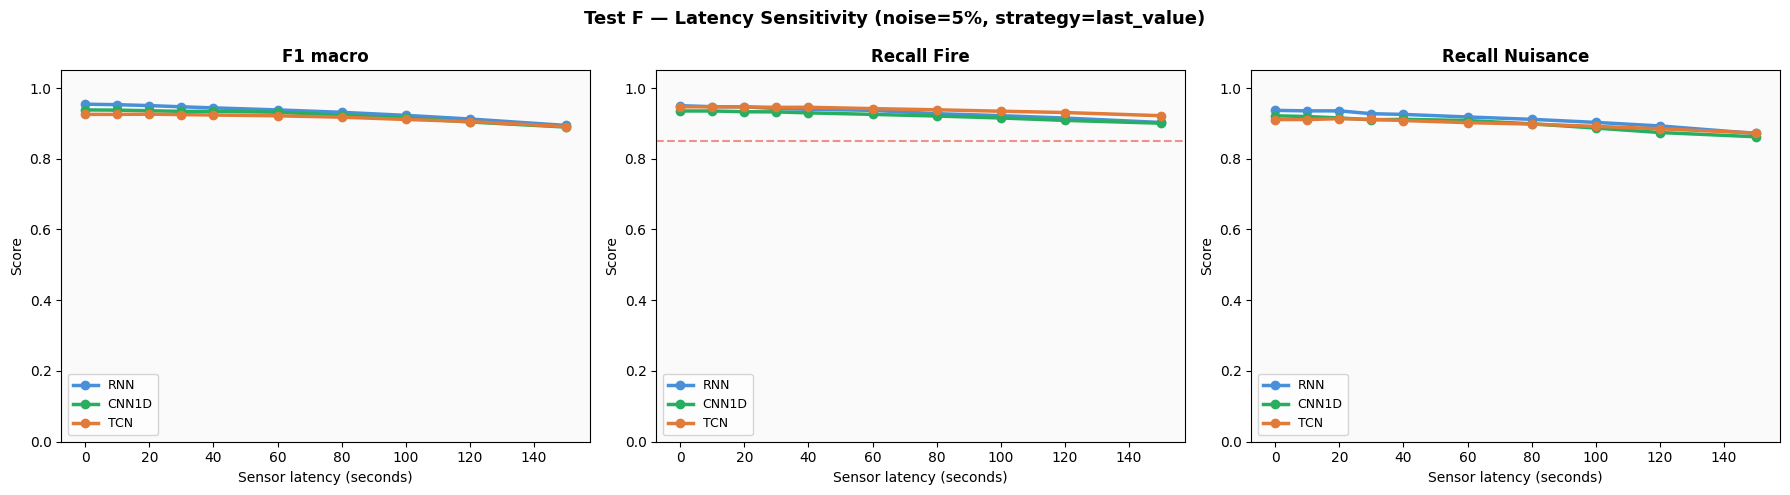

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Test F — Latency Sensitivity (noise={NOISE_STREAM*100:.0f}%, strategy=last_value)',
    fontsize=13, fontweight='bold'
)

for ax, metric, title in zip(axes,
    ['f1_macro', 'recall_fire', 'recall_nuis'],
    ['F1 macro', 'Recall Fire', 'Recall Nuisance']):
    for name, color in MODEL_COLORS.items():
        lat_sec = [l * 10 for l in LATENCY_RANGE]   # convert steps to seconds
        ax.plot(lat_sec, latency_results[name][metric],
                color=color, linewidth=2.5, marker='o', markersize=6, label=name)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Sensor latency (seconds)')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    if metric == 'recall_fire':
        ax.axhline(0.85, color='#E74C3C', lw=1.5, ls='--', alpha=0.6, label='0.85')
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()

## 10. Overall Robustness Summary

In [ ]:
# Compute robustness score:
#   area under the F1-macro curve across noise levels (Test A)
#   area under the recall_fire curve across pad levels (Test B, last_value)
import numpy as np

summary_rows = []
for name in models:
    # Noise robustness: AUC of F1-macro vs noise
    noise_f1s = [noise_df.xs(name).query('noise_pct == @lvl')['f1_macro'].values[0]
                 for lvl in NOISE_LEVELS]
    noise_auc = float(np.trapz(noise_f1s, [l * 100 for l in NOISE_LEVELS])) / 50.0

    # Pad robustness: AUC of recall_fire vs pad_pct (last_value)
    pad_rf = [pad_results['last_value'].xs(name).query('pad_steps == @ps')['recall_fire'].values[0]
              for ps in PAD_STEPS]
    pad_pct_vals = [ps / WINDOW_SIZE * 100 for ps in PAD_STEPS]
    pad_auc = float(np.trapz(pad_rf, pad_pct_vals)) / (max(pad_pct_vals) or 1)

    # Streaming score
    stream_m = compute_metrics(stream_results[name]['trues'], stream_results[name]['preds'])

    summary_rows.append({
        'Model':                name,
        'Baseline F1':          baseline[name]['f1_macro'],
        'Noise robustness AUC': round(noise_auc, 4),
        'Pad robustness AUC':   round(pad_auc, 4),
        'Stream F1':            stream_m['f1_macro'],
        'Stream Recall Fire':   stream_m['recall_fire'],
        'Stream Recall Nuis':   stream_m['recall_nuis'],
    })

summary = pd.DataFrame(summary_rows).set_index('Model')

print('=== Overall Robustness Summary ===')
display(
    summary.style
    .highlight_max(
        subset=['Baseline F1', 'Noise robustness AUC', 'Pad robustness AUC',
                'Stream F1', 'Stream Recall Fire'],
        color='#d4f1d4'
    )
    .format('{:.4f}')
)

=== Overall Robustness Summary ===


,Baseline F1,Noise robustness AUC,Pad robustness AUC,Stream F1,Stream Recall Fire,Stream Recall Nuis
Model,,,,,,
RNN,0.9548,0.9392,0.9253,0.9381,0.9368,0.9181
CNN1D,0.9377,0.9389,0.9178,0.9316,0.9255,0.9081
TCN,0.9259,0.9242,0.9356,0.9214,0.9417,0.9021


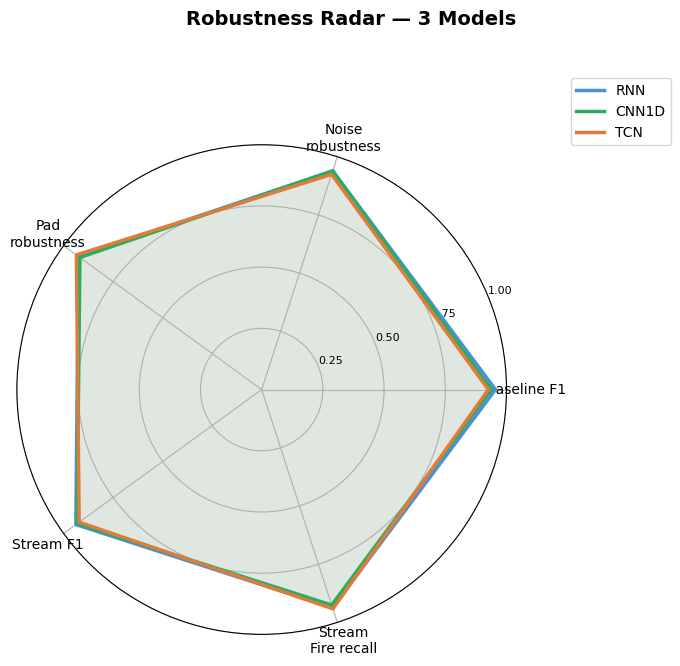

In [ ]:
# Radar / spider chart for 3 models
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = [
    'Baseline F1', 'Noise\nrobustness', 'Pad\nrobustness',
    'Stream F1', 'Stream\nFire recall',
]
N_cat = len(categories)
angles = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
fig.suptitle('Robustness Radar — 3 Models', fontsize=14, fontweight='bold')

cols_map = {
    'Baseline F1':          'Baseline F1',
    'Noise\nrobustness':    'Noise robustness AUC',
    'Pad\nrobustness':      'Pad robustness AUC',
    'Stream F1':            'Stream F1',
    'Stream\nFire recall':  'Stream Recall Fire',
}

for name, color in MODEL_COLORS.items():
    vals = [summary.loc[name, v] for v in cols_map.values()]
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, color=color, linewidth=2.5, label=name)
    ax.fill(angles, vals_plot, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print('=' * 62)
print('STREAMING ROBUSTNESS VERDICT')
print('=' * 62)

for name in models:
    r = summary.loc[name]
    print(f'\n── {name} ──')
    print(f'  Baseline F1 macro  : {r["Baseline F1"]:.4f}')
    print(f'  Noise AUC (higher=more robust): {r["Noise robustness AUC"]:.4f}')
    print(f'  Pad AUC  (higher=more robust): {r["Pad robustness AUC"]:.4f}')
    print(f'  Streaming F1 macro : {r["Stream F1"]:.4f}')
    print(f'  Streaming Fire recall: {r["Stream Recall Fire"]:.4f}')

best_noise = summary['Noise robustness AUC'].idxmax()
best_pad   = summary['Pad robustness AUC'].idxmax()
best_stream = summary['Stream F1'].idxmax()

print()
print(f'Most noise-robust  : {best_noise}')
print(f'Most pad-robust    : {best_pad}')
print(f'Best streaming F1  : {best_stream}')
print()
print('Deploy recommendation:')
print('  Batch offline  → RNN (best clean accuracy)')
print('  Streaming/IoT  → CNN-1D or TCN (robust to padding latency)')
print('  Noisy env.     → add Gaussian noise augmentation during training')

STREAMING ROBUSTNESS VERDICT

── RNN ──
  Baseline F1 macro  : 0.9548
  Noise AUC (higher=more robust): 0.9392
  Pad AUC  (higher=more robust): 0.9253
  Streaming F1 macro : 0.9381
  Streaming Fire recall: 0.9368

── CNN1D ──
  Baseline F1 macro  : 0.9377
  Noise AUC (higher=more robust): 0.9389
  Pad AUC  (higher=more robust): 0.9178
  Streaming F1 macro : 0.9316
  Streaming Fire recall: 0.9255

── TCN ──
  Baseline F1 macro  : 0.9259
  Noise AUC (higher=more robust): 0.9242
  Pad AUC  (higher=more robust): 0.9356
  Streaming F1 macro : 0.9214
  Streaming Fire recall: 0.9417

Most noise-robust  : RNN
Most pad-robust    : TCN
Best streaming F1  : RNN

Deploy recommendation:
  Batch offline  → RNN (best clean accuracy)
  Streaming/IoT  → CNN-1D or TCN (robust to padding latency)
  Noisy env.     → add Gaussian noise augmentation during training
